# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import optuna
import numpy as np
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sweetviz as sv

import shap
import joblib

# Load Model

In [2]:
xgb_all = joblib.load("xgb_all_701515.pkl")
xgb_smooth = joblib.load("xgb_smooth_701515.pkl")
xgb_erractic = joblib.load("xgb_erractic_701515.pkl")
xgb_intermittent = joblib.load("xgb_intermittent_701515.pkl")
xgb_lumpy = joblib.load("xgb_lumpy_701515.pkl")

tabnet_all = TabNetRegressor()
tabnet_all.load_model("tabnet_all_701515.zip")

tabnet_smooth = TabNetRegressor()
tabnet_smooth.load_model("tabnet_smooth_701515.zip")

tabnet_erractic = TabNetRegressor()
tabnet_erractic.load_model("tabnet_erractic_701515.zip")

tabnet_intermittent = TabNetRegressor()
tabnet_intermittent.load_model("tabnet_intermittent_701515.zip")

tabnet_lumpy = TabNetRegressor()
tabnet_lumpy.load_model("tabnet_lumpy_701515.zip")

c:\Users\amand\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


# 1. Data Understanding

## 1.1 Data Collection

In [3]:
df = pd.read_csv('dataset.csv')
master_konversi = pd.read_csv('master_konversi (2).csv')

In [4]:
df

,Id,Id Transaksi,Nama Barang,Qty,Satuan,Harga,Total Harga,Diskon,SubTotal,Tanggal Transaksi
0,#43270,#17403,TUTUP CEMBUNG POLOS,8,Pack,Rp4.000,Rp32.000,Rp-,Rp32.000,31/07/2024 10:22:00
1,#43261,#17402,GELAS SLIM 'TEN-TEN' 18 OZ,9,Pack,Rp7.500,Rp67.500,Rp-,Rp67.500,31/07/2024 10:21:00
2,#43262,#17402,TUTUP CEMBUNG ULIR,1,Pack,Rp4.000,Rp4.000,Rp-,Rp4.000,31/07/2024 10:21:00
3,#43263,#17402,MIKA 7XC TECHNO,2,Pack,Rp5.000,Rp10.000,Rp-,Rp10.000,31/07/2024 10:21:00
4,#43264,#17402,SENDOK MKN VICTORY - PUTIH SUSU,1,Pack,Rp12.000,Rp12.000,Rp-,Rp12.000,31/07/2024 10:21:00
...,...,...,...,...,...,...,...,...,...,...
57674,#43148,#17394,HD KALONG 40,1,Pack,Rp17.000,Rp17.000,Rp-,Rp17.000,02/01/2026 7:44:25
57675,#43145,#17393,SENDOK MKN TOP PP - PUTIH SUSU 25 PCS,2,Pack,Rp3.000,Rp6.000,Rp-,Rp6.000,02/01/2026 7:34:06
57676,#43146,#17393,HD SAMPAH FAMILY 60 X 100,2,Pcs,Rp2.000,Rp4.000,Rp-,Rp4.000,02/01/2026 7:34:06
57677,#43612,#17392,FOAM KCS 2,1,Bal,Rp29.500,Rp29.500,Rp-,Rp29.500,02/01/2026 7:31:00


In [5]:
master_konversi

,Nama Barang,Dari Satuan,Ke Satuan Final,Multiplier
0,BESEK,BAL,KODI,18
1,BESEK TELOR CEPER,PCS,KODI,"0,05"
2,BESEK TELUR TEBAL,BAL,KODI,18
3,BOTOL ALMOND 250ML,BAL,PCS,100
4,BOTOL CABE 200ML,BAL,PCS,100
...,...,...,...,...
137,TOPLES TABUNG 600 ML ISI 50,BAL,PCS,50
138,TOPLES TABUNG 800 ML - TEBAL,BAL,PCS,60
139,TUSUK SATE SWAN,DUS,PACK,60
140,TUTUP CEMBUNG POLOS,DUS,PACK,40


## 1.2 Data Description

### a. Cek Tipe Data

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57679 entries, 0 to 57678
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 57679 non-null  str  
 1   Id Transaksi       57679 non-null  str  
 2   Nama Barang        57679 non-null  str  
 3   Qty                57679 non-null  int64
 4   Satuan             57243 non-null  str  
 5   Harga              57679 non-null  str  
 6   Total Harga        57679 non-null  str  
 7   Diskon             57679 non-null  str  
 8   SubTotal           57679 non-null  str  
 9   Tanggal Transaksi  57679 non-null  str  
dtypes: int64(1), str(9)
memory usage: 8.8 MB


## 1.3 Data Exploration

### Statistik Deskriptif, Visualisasi Data, Korelasi Antar Variabel

In [7]:
report = sv.analyze(df)
#report.show_html("report.html")

                                             |          | [  0%]   00:00 -> (? left)

## 1.4 Data Quality Verification

### a. Deteksi Missing Value

In [8]:
df.isna().sum()

Id                     0
Id Transaksi           0
Nama Barang            0
Qty                    0
Satuan               436
Harga                  0
Total Harga            0
Diskon                 0
SubTotal               0
Tanggal Transaksi      0
dtype: int64

### b. Deteksi Data Duplikat

In [9]:
df.duplicated().sum()

np.int64(0)

### c. Deteksi Outliers

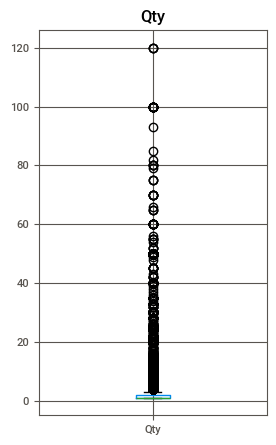

In [10]:
plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
plt.title("Qty")
df.boxplot('Qty')
plt.show()

# 2. Data Preparation

## 2.1 Data Selection

In [11]:
df = df.drop(['Id', 'Id Transaksi','Diskon','SubTotal'],axis=1)
df

,Nama Barang,Qty,Satuan,Harga,Total Harga,Tanggal Transaksi
0,TUTUP CEMBUNG POLOS,8,Pack,Rp4.000,Rp32.000,31/07/2024 10:22:00
1,GELAS SLIM 'TEN-TEN' 18 OZ,9,Pack,Rp7.500,Rp67.500,31/07/2024 10:21:00
2,TUTUP CEMBUNG ULIR,1,Pack,Rp4.000,Rp4.000,31/07/2024 10:21:00
3,MIKA 7XC TECHNO,2,Pack,Rp5.000,Rp10.000,31/07/2024 10:21:00
4,SENDOK MKN VICTORY - PUTIH SUSU,1,Pack,Rp12.000,Rp12.000,31/07/2024 10:21:00
...,...,...,...,...,...,...
57674,HD KALONG 40,1,Pack,Rp17.000,Rp17.000,02/01/2026 7:44:25
57675,SENDOK MKN TOP PP - PUTIH SUSU 25 PCS,2,Pack,Rp3.000,Rp6.000,02/01/2026 7:34:06
57676,HD SAMPAH FAMILY 60 X 100,2,Pcs,Rp2.000,Rp4.000,02/01/2026 7:34:06
57677,FOAM KCS 2,1,Bal,Rp29.500,Rp29.500,02/01/2026 7:31:00


## 2.2 Data Cleaning

### a. Mengedit Penulisan Harga

In [12]:
for col in ['Harga', 'Total Harga']:
    df[col] = (
        df[col]
        .str.replace('Rp', '', regex=False)
        .str.replace('.', '', regex=False)
    )

### b. Mengubah Tipe Data Kolom Qty, Harga, Total Harga & Tanggal Transaksi                                                                         

In [13]:
df['Qty'] = df['Qty'].astype(float)
df['Harga'] = df['Harga'].astype(int)
df['Total Harga'] = df['Total Harga'].astype(int)
df['Tanggal Transaksi'] = pd.to_datetime(df['Tanggal Transaksi']) \
    .dt.strftime('%d-%m-%Y')

C:\Users\amand\AppData\Local\Temp\ipykernel_31816\3131157929.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Tanggal Transaksi'] = pd.to_datetime(df['Tanggal Transaksi']) \


### c. Menangani Missing Value pada Kolom Satuan

In [14]:
df['Nama Barang'] = df['Nama Barang'].str.upper()

In [15]:
missing_row = df[df.isnull().any(axis=1)]
missing_row['Nama Barang'].unique()

<ArrowStringArray>
[ 'GARPU KUE/BUAH THREE STAR',           'NUTRIJELL RANDOM',
     'SARUNG TANGAN KHARISMA',             'HD KRESEK ECER',
 'JOLLY FACIAL SOFTPACK 250S',         'SEAL CUP TOS FRUIT',
             'KLIR SQ 120 ML', 'PASEO SMART FACIAL 540 PLY',
  'WIPES SANITIZER - SANITER']
Length: 9, dtype: str

In [16]:
SATUAN_NULL_FIX = {
        "NUTRIJELL RANDOM":         "Sachet",
        "HD KRESEK ECER":           "Pcs",
        "JOLLY FACIAL SOFTPACK 250S": "Pack",
        "SARUNG TANGAN KHARISMA":   "Pack",
        "GARPU KUE/BUAH THREE STAR": "Pack",
        "KLIR SQ 120 ML":           "Pack",
        "WIPES SANITIZER - SANITER": "Pack",
        "PASEO SMART FACIAL 540 PLY": "Pack",
        "SEAL CUP TOS FRUIT":       "Roll",
    }

for nama, satuan in SATUAN_NULL_FIX.items():
    mask = (df["Nama Barang"] == nama) & (df["Satuan"].isnull())
    df.loc[mask, "Satuan"] = satuan

### d. Mengatasi Inkonsisten Penulisan pada Kolom Satuan

In [17]:
df['Satuan'] = df['Satuan'].str.upper()

In [18]:
df['Satuan'].unique()

<ArrowStringArray>
[  'PACK',    'DUS',   'IKAT', 'KEPING',    'PCS',    'BAL',   'ROLL',
     'GR',  'KOTAK',   'SLOP', 'SACHET',   'KOLI',     'KG',  'METER',
   'KODI',      'M',   'BALL',    'SAK',   'GRAM']
Length: 19, dtype: str

In [19]:
df["Satuan"] = df["Satuan"].replace({
        "BALL": "BAL", "GR": "GRAM", "M": "METER",
    })

### e. Mengatasi Penamaan Produk Belum Tepat

In [20]:
# Melihat Transaksi per Barang dalam Satuan Berbeda

jumlah_transaksi_1 = (
    df.groupby(['Nama Barang', 'Satuan'])
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values(['Nama Barang', 'Satuan'])
)

jumlah_transaksi_1

,Nama Barang,Satuan,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50) + LID,BAL,2
1,A. FOIL OIV-450 (400/50) + LID - 10PCS,PACK,36
2,A. FOIL OIV-450 (400/50) - 10PCS,PACK,16
3,A. FOIL OV-290 (258/36) + LID,BAL,76
4,A. FOIL OV-290 (258/36) - 10PCS,PACK,6
...,...,...,...
1124,VICTORY SQ 3000 ML,PACK,4
1125,VICTORY SQ 3000 ML,PCS,1
1126,VICTORY TUTUP INJECTION,PACK,1
1127,WIPES SANITIZER - SANITER,PACK,6


In [21]:
# Melihat Transaksi per Barang sehingga mendapatkan Data Unik Barang

cek_barang = (
    df.groupby('Nama Barang')
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values('Nama Barang')
)

cek_barang

,Nama Barang,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50) + LID,2
1,A. FOIL OIV-450 (400/50) + LID - 10PCS,36
2,A. FOIL OIV-450 (400/50) - 10PCS,16
3,A. FOIL OV-290 (258/36) + LID,76
4,A. FOIL OV-290 (258/36) - 10PCS,6
...,...,...
776,VICTORY SQ 2000 ML,11
777,VICTORY SQ 3000 ML,6
778,VICTORY TUTUP INJECTION,1
779,WIPES SANITIZER - SANITER,6


In [22]:
df_abc = df.copy()
df_abc

,Nama Barang,Qty,Satuan,Harga,Total Harga,Tanggal Transaksi
0,TUTUP CEMBUNG POLOS,8.0,PACK,4000,32000,31-07-2024
1,GELAS SLIM 'TEN-TEN' 18 OZ,9.0,PACK,7500,67500,31-07-2024
2,TUTUP CEMBUNG ULIR,1.0,PACK,4000,4000,31-07-2024
3,MIKA 7XC TECHNO,2.0,PACK,5000,10000,31-07-2024
4,SENDOK MKN VICTORY - PUTIH SUSU,1.0,PACK,12000,12000,31-07-2024
...,...,...,...,...,...,...
57674,HD KALONG 40,1.0,PACK,17000,17000,02-01-2026
57675,SENDOK MKN TOP PP - PUTIH SUSU 25 PCS,2.0,PACK,3000,6000,02-01-2026
57676,HD SAMPAH FAMILY 60 X 100,2.0,PCS,2000,4000,02-01-2026
57677,FOAM KCS 2,1.0,BAL,29500,29500,02-01-2026


In [23]:
def rename_produk_abc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    RENAME_MAP = [
        (["A. FOIL OV-290 (258/36) + LID", "A. FOIL OV-290 (258/36) - 10PCS"],       "A. FOIL OV-290 (258/36)"),
        (["A. FOIL OX-100 (111/34) + LID", "A. FOIL OX-100 (111/34) + LID - 10PCS"], "A. FOIL OX-100 (111/34)"),
        (["A. FOIL OX-1550 (1450/44) + LID"],                                          "A. FOIL OX-1550 (1450/44)"),
        (["ANTAKA BALADO - 10PCS"],                                                     "ANTAKA BALADO"),
        (["ANTAKA CAE BUBUK TUM-TUM - 10PCS", "ANTAKA CAE BUBUK TUM-TUM"],            "ANTAKA CABE BUBUK TUM-TUM"),
        (["ANTAKA JAGUNG MANIS - 10PCS"],                                               "ANTAKA JAGUNG MANIS"),
        (["BESEK - 1 KODI", "BESEK TELOR CEPER", "BESEK TELUR TEBAL", "BESEK TELUR TEBAL - 1 KODI"], "BESEK"),
        (["CREAMER NDC DONGXIAO 1 KG", "CREAMER NDC DONGXIAO 250 GR", "CREAMER NDC DONGXIAO 500 GR"], "CREAMER NDC DONGXIAO"),
        (["DM BENTO SEKAT 4 - LB 401S"],   "DM BENTO SEKAT 4"),
        (["DM RO 400 ML"],                  "DM R 400 ML"),
        (["DM 50 ML"],                      "DM SAUCE 50 ML"),
        (["GELAS 16 OZ BEST TEH TECHNO"],   "GELAS BEST TEH TECHNO 16 OZ"),
        (["GELAS 18 OZ SLIM 'TEN-TEN'"],    "GELAS SLIM 'TEN-TEN' 18 OZ"),
        (["GELAS 22 OZ SLIM 'TEN-TEN'"],    "GELAS SLIM 'TEN-TEN' 22 OZ"),
        (["GELAS TECHNO 22 OZ SLIM"],       "GELAS SLIM TECHNO 22 OZ"),
        (["GELAS TENTEN 18 OZ REGULER"],    "GELAS TENTEN 18 OZ"),
        (["GELAS TEN TEN 14 OZ"],           "GELAS TENTEN 14 OZ"),
        (["GELAS TEN TEN 16 OZ"],           "GELAS TENTEN 16 OZ"),
        (["JOLLY FACIAL SOFTPACK 200S - 3PACK"], "JOLLY FACIAL SOFTPACK 200S - 3 PACK"),
        (["KARET SMILE - KUNING - 10 PACK"], "KARET SMILE - KUNING"),
        (["KARET SMILE - MERAH - 10 PACK"],  "KARET SMILE - MERAH"),
        (["KERTAS ROTI - PUTIH *10", "KERTAS ROTI - PUTIH *5"], "KERTAS ROTI - PUTIH"),
        (["MIKA BG 225 - BENING (10PCS)", "MIKA BG 225 - BENING (20PCS)"], "MIKA BG 225 - BENING"),
        (["MIKA BGT 225 ISI 10 PCS"],       "MIKA BGT 225"),
        (["MIKA BGT 25 - 50 PCS"],          "MIKA BGT 25"),
        (["MIKA MB  BUAH 100"],             "MIKA MB BUAH 100"),
        (["MIKA TUMPENG CT - 20 MMPG"],     "MIKA TUMPENG CT - 20"),
        (["ORIPACK NPN S - 10 PCS"],        "ORIPACK NPN S"),
        (["PE TOMAT - 50 X 75 - 1 IKAT", "PE TOMAT - 50 X 75 - 1 PACK", "PE TOMAT - 50 X 75 - 2 PACK"], "PE TOMAT - 50 X 75"),
        (["PITA TP ROTI MIX 1KG", "PITA TP ROTI MIX 250GR", "PITA TP ROTI MIX 500GR"], "PITA TP ROTI MIX"),
        (["TEPUNG ROTI BINTANG 10 KG", "TEPUNG ROTI BINTANG 1KG", "TEPUNG ROTI BINTANG 250GR", "TEPUNG ROTI BINTANG 500GR"], "TEPUNG ROTI BINTANG"),
        (["TEPUNG ROTI JAWARA MIX - 500 GR", "TEPUNG ROTI JAWARA MIX - 1 KG"], "TEPUNG ROTI JAWARA MIX"),
        (["TOPLES TABUNG 600 ML ISI 35", "TOPLES TABUNG 600 ML ISI 50"], "TOPLES TABUNG 600 ML"),
        (["HDPE ATP TIGER - 15 X30"],       "HDPE ATP TIGER - 15 X 30"),
        (["HDPEX BENING 30"],               "HD PEX BENING 30"),
        (["KOTAK ASHLEY POLOS 20 X 20 - P.T"], "KOTAK ASHELY POLOS 20 X 20 - P.T"),
        (["PP MAKHOTA 07 X 12 X 25"],       "PP MAHKOTA 07 X 12 X 25"),
        (["PP MAKHOTA 07 X 15 X 25"],       "PP MAHKOTA 07 X 15 X 25"),
        (["PP MAKHOTA 07 X 15 X 30"],       "PP MAHKOTA 07 X 15 X 30"),
        (["PP MAKHOTA 07 X 17 X 25"],       "PP MAHKOTA 07 X 17 X 25"),
        (["PP MAKHOTA 07 X 17 X 30"],       "PP MAHKOTA 07 X 17 X 30"),
        (["PP MAKHOTA 07 X 17 X 35"],       "PP MAHKOTA 07 X 17 X 35"),
        (["PP MAKHOTA 07 X 20 X 35"],       "PP MAHKOTA 07 X 20 X 35"),
    ]

    df.loc[
        df["Nama Barang"].str.contains(r"^A\. FOIL OIV-450 \(400/50\)", regex=True, na=False),
        "Nama Barang"
    ] = "A. FOIL OIV-450 (400/50)"

    for nama_lama_list, nama_baru in RENAME_MAP:
        df.loc[df["Nama Barang"].isin(nama_lama_list), "Nama Barang"] = nama_baru

    BUNDLE_SPLITS = [
        ("NESTO PAPER BOWL + LID 360 ML",         "NESTO PAPER BOWL 360 ML",         "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 360 ML - KRAFT",  "NESTO PAPER BOWL 360 ML - KRAFT", "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 500 ML",          "NESTO PAPER BOWL 500 ML",         "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 500 ML - KRAFT",  "NESTO PAPER BOWL 500 ML - KRAFT", "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 650 ML",          "NESTO PAPER BOWL 650 ML",         "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 650 ML - KRAFT",  "NESTO PAPER BOWL 650 ML - KRAFT", "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 800 ML",          "NESTO PAPER BOWL 800 ML",         "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 800 ML - KRAFT",  "NESTO PAPER BOWL 800 ML - KRAFT", "LID TUTUP 650/800 ML"),
    ]

    def _mode_harga(nama, satuan=None):
        q = df[df["Nama Barang"] == nama]
        if satuan:
            q = q[q["Satuan"] == satuan]
        if q.empty:
            return 0
        return int(q["Harga"].mode()[0]) if not q["Harga"].mode().empty else 0

    bundle_names = [b[0] for b in BUNDLE_SPLITS]
    dfs = [df[~df["Nama Barang"].isin(bundle_names)]]

    for bundle_name, bowl_name, lid_name in BUNDLE_SPLITS:
        mask = df["Nama Barang"] == bundle_name
        if not mask.any():
            continue
        data = df[mask].copy()

        harga_bowl = _mode_harga(bowl_name, "PACK")
        harga_lid  = _mode_harga(lid_name, "PACK")
        if bundle_name == "NESTO PAPER BOWL + LID 500 ML - KRAFT" and harga_bowl == 0:
            harga_bowl = 12000

        df_bowl = data.copy()
        df_bowl["Nama Barang"] = bowl_name
        df_bowl["Satuan"]      = "PACK"
        df_bowl["Harga"]       = harga_bowl
        df_bowl["Total Harga"] = (df_bowl["Qty"] * harga_bowl).astype(int)

        df_lid = data.copy()
        df_lid["Nama Barang"]  = lid_name
        df_lid["Satuan"]       = "PACK"
        df_lid["Harga"]        = harga_lid
        df_lid["Total Harga"]  = (df_lid["Qty"] * harga_lid).astype(int)

        dfs.extend([df_bowl, df_lid])

    df = pd.concat(dfs, ignore_index=True)
    return df.sort_values("Tanggal Transaksi").reset_index(drop=True)

df_abc = rename_produk_abc(df_abc)

In [24]:
# Melihat Transaksi per Barang dalam Satuan Berbeda - After Cleaning

jumlah_transaksi_2 = (
    df_abc.groupby(['Nama Barang', 'Satuan'])
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values(['Nama Barang', 'Satuan'])
)

jumlah_transaksi_2

,Nama Barang,Satuan,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50),BAL,2
1,A. FOIL OIV-450 (400/50),PACK,52
2,A. FOIL OV-290 (258/36),BAL,76
3,A. FOIL OV-290 (258/36),PACK,6
4,A. FOIL OX-100 (111/34),BAL,26
...,...,...,...
1071,VICTORY SQ 3000 ML,PACK,4
1072,VICTORY SQ 3000 ML,PCS,1
1073,VICTORY TUTUP INJECTION,PACK,1
1074,WIPES SANITIZER - SANITER,PACK,6


In [25]:
# Melihat Transaksi per Barang sehingga mendapatkan Data Unik Barang - After Cleaning

cek_barang_2 = (
    df_abc.groupby('Nama Barang')
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values('Nama Barang')
)

cek_barang_2

,Nama Barang,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50),54
1,A. FOIL OV-290 (258/36),82
2,A. FOIL OX-100 (111/34),26
3,A. FOIL OX-1550 (1450/44),127
4,AGAR SWALLOW WALET SUN - PUTIH,75
...,...,...
713,VICTORY SQ 2000 ML,11
714,VICTORY SQ 3000 ML,6
715,VICTORY TUTUP INJECTION,1
716,WIPES SANITIZER - SANITER,6


### f. Format Ulang Penulisan Tanggal Transaksi

In [26]:
df_abc['Tanggal Transaksi'] = pd.to_datetime(
    df_abc['Tanggal Transaksi'],
    format='%d-%m-%Y'
)

df_abc = df_abc.sort_values('Tanggal Transaksi').reset_index(drop=True)
df_abc

,Nama Barang,Qty,Satuan,Harga,Total Harga,Tanggal Transaksi
0,NESTO PAPER BOWL 500 ML,1.0,PACK,13000,13000,2024-07-01
1,FOAM KCS 3,12.0,PCS,450,5400,2024-07-01
2,PE 55 - 20 X 35,1.0,KEPING,8000,8000,2024-07-01
3,LID TUTUP 650/800 ML,1.0,PACK,10000,10000,2024-07-01
4,MIKA BROWNIES L TECHNO - PET,1.0,PACK,70000,70000,2024-07-01
...,...,...,...,...,...,...
58489,HDPE ATP TIGER - 15 X 30,1.0,KEPING,10500,10500,2026-01-04
58490,JOLLY KULINER,1.0,PACK,12000,12000,2026-01-04
58491,PE 55 - 15 X 30,1.0,KEPING,8000,8000,2026-01-04
58492,KERTAS CAP GAJAH UNGU,1.0,PACK,29500,29500,2026-01-04


# 3. Data Aggregation for ABC Analysis

### a. Menjumlahkan Total Pendapatan per Barang

In [27]:
total_penjualan = df_abc.groupby('Nama Barang', as_index=False)['Total Harga'] \
                  .sum().sort_values('Total Harga',ascending=False)
total_penjualan.reset_index(drop=True, inplace=True)

total_penjualan

,Nama Barang,Total Harga
0,KOTAK GS POLOS 12 X 12,26449508
1,FOAM KCS 2,22554811
2,GELAS SLIM 'TEN-TEN' 18 OZ,20105000
3,MAMAYO ORIGINAL - 1 KG,19890000
4,NESTO PAPER BOWL 650 ML,18529000
...,...,...
713,PP MATAHARI 16 X 40,8500
714,ANTAKA CABE BANG,8000
715,LB BENING BESAR,8000
716,HD SP 60 X 100 - UNGU,6000


# 4. Analisis ABC

### a. Perhitungan Total Produk per Grup

In [28]:
n = len(total_penjualan)
n_a = round(n * 0.2)
n_b = round(n * 0.3)
n_c = n - (n_a + n_b)

grup_a = total_penjualan.iloc[:n_a]
grup_b = total_penjualan.iloc[n_a:n_a + n_b]
grup_c = total_penjualan.iloc[n_a + n_b:]

print("Total Produk A = ",n_a)
print("Total Produk B = ",n_b)
print("Total Produk C = ",n_c)

Total Produk A =  144
Total Produk B =  215
Total Produk C =  359


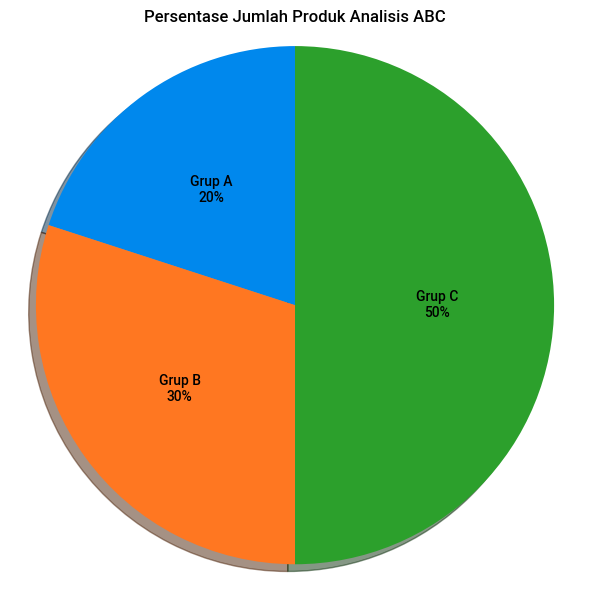

In [29]:
nilai_a = round(n_a / n * 100)
nilai_b = round(n_b / n * 100)
nilai_c = round(n_c / n * 100)

sizes = [nilai_a, nilai_b, nilai_c]

labels = [
    f"Grup A\n{nilai_a:.0f}%",
    f"Grup B\n{nilai_b:.0f}%",
    f"Grup C\n{nilai_c:.0f}%"
]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    startangle=90,
    labeldistance=0.55,
    shadow=True,
    textprops={
        'fontsize': 10,
        'fontweight': 'bold',
        'color': 'black',
        'ha': 'center'
    }
)

ax.axis('equal')
plt.title('Persentase Jumlah Produk Analisis ABC')
plt.tight_layout()
plt.show()

### b. Perhitungan Total Pendapatan per Grup 

In [30]:
pendapatan_all = total_penjualan['Total Harga'].sum()
pendapatan_a = grup_a['Total Harga'].sum()
pendapatan_b = grup_b['Total Harga'].sum()
pendapatan_c = grup_c['Total Harga'].sum()

print("Total Pendapatan : ",pendapatan_all)
print("Total Pendapatan Grup A: ", pendapatan_a)
print("Total Pendapatan Grup B: ", pendapatan_b)
print("Total Pendapatan Grup C: ", pendapatan_c)

Total Pendapatan :  1378840936
Total Pendapatan Grup A:  1018896526
Total Pendapatan Grup B:  279905370
Total Pendapatan Grup C:  80039040


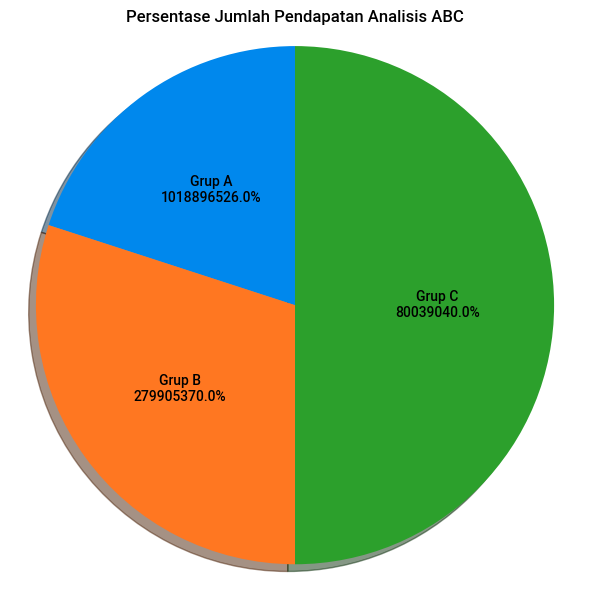

In [31]:
total = sum(sizes)

labels = [
    f"Grup A\n{pendapatan_a/total*100:.1f}%",
    f"Grup B\n{pendapatan_b/total*100:.1f}%",
    f"Grup C\n{pendapatan_c/total*100:.1f}%"
]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    startangle=90,
    shadow=True,
    labeldistance=0.55,
    textprops={
        'fontsize': 10,
        'fontweight': 'bold',
        'color': 'black',
        'ha': 'center'
    }
)

ax.axis('equal')
plt.title('Persentase Jumlah Pendapatan Analisis ABC')
plt.tight_layout()
plt.show()

### c. Visualisasi Persentase Produk dan Pendapatan

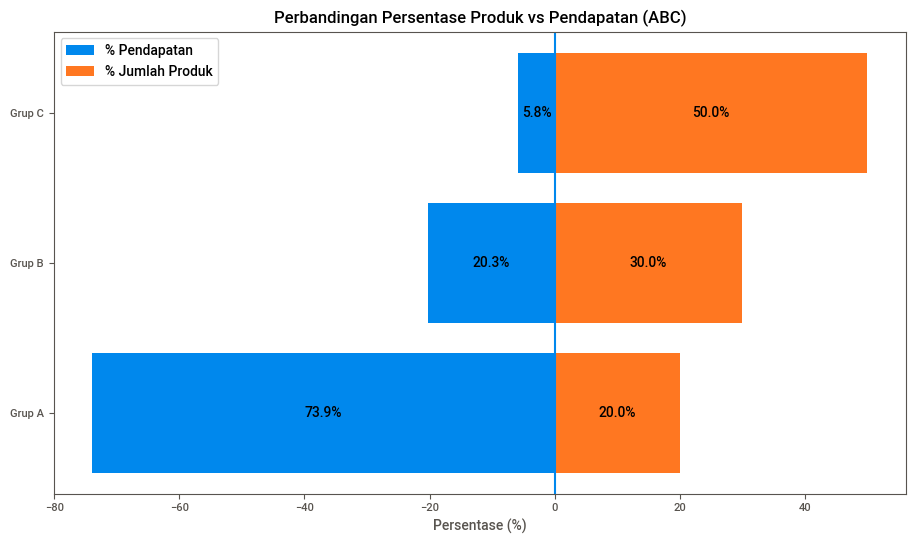

In [32]:
pendapatan_a = (pendapatan_a/pendapatan_all)*100
pendapatan_b = (pendapatan_b/pendapatan_all)*100
pendapatan_c = (pendapatan_c/pendapatan_all)*100

labels = ['Grup A', 'Grup B', 'Grup C']

produk = [nilai_a, nilai_b, nilai_c]
pendapatan = [pendapatan_a, pendapatan_b, pendapatan_c]

fig, ax = plt.subplots(figsize=(11,6))

ax.barh(labels, [-p for p in pendapatan], label='% Pendapatan')
ax.barh(labels, produk, label='% Jumlah Produk')

ax.axvline(0)

for i in range(len(labels)):
    ax.text(-pendapatan[i]/2, i,
            f"{pendapatan[i]:.1f}%",
            va='center', ha='center', color='black')

    ax.text(produk[i]/2, i,
            f"{produk[i]:.1f}%",
            va='center', ha='center', color='black')

ax.set_xlabel('Persentase (%)')
ax.set_title('Perbandingan Persentase Produk vs Pendapatan (ABC)')
ax.legend()

plt.show()

# 5. Data Aggregation & Preparation for Modeling

## 5.1 Data Preparation for Modeling 

### a. Menghapus Kolom Total Harga, Harga

In [33]:
df = df.drop(['Harga','Total Harga'], axis=1)
df = df.sort_values('Tanggal Transaksi').reset_index(drop=True)
df

,Nama Barang,Qty,Satuan,Tanggal Transaksi
0,NESTO PAPER BOWL + LID 650 ML,4.0,PACK,01-02-2025
1,KERTAS PADANG,2.0,ROLL,01-02-2025
2,SENDOK BEBEK VICTORY - PUTIH SUSU,1.0,PACK,01-02-2025
3,GELAS TECHNO 12 OZ,3.0,PACK,01-02-2025
4,HD TROYA 15,1.0,PACK,01-02-2025
...,...,...,...,...
57674,GELAS SLIM 'TEN-TEN' 18 OZ,2.0,PACK,31-12-2025
57675,SENDOK MKN IRIT - BENING,1.0,PACK,31-12-2025
57676,PE 55 - 15 X 30,1.0,KEPING,31-12-2025
57677,HD LOS BENING 24 - 9 ONS,2.0,IKAT,31-12-2025


### b. Koreksi Beberapa Produk Grup A di Data

In [34]:
def rename_produk_model(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    RENAME_MODEL = [
        (["GELAS 18 OZ SLIM 'TEN-TEN'"], "GELAS SLIM 'TEN-TEN' 18 OZ"),
        (["GELAS 22 OZ SLIM 'TEN-TEN'"], "GELAS SLIM 'TEN-TEN' 22 OZ"),
        (["GELAS TENTEN 18 OZ REGULER"], "GELAS TENTEN 18 OZ"),
        (["GELAS TEN TEN 16 OZ"],        "GELAS TENTEN 16 OZ"),
        (["HDPE ATP TIGER - 15 X30"],    "HDPE ATP TIGER - 15 X 30"),
    ]
    for nama_lama_list, nama_baru in RENAME_MODEL:
        df.loc[df["Nama Barang"].isin(nama_lama_list), "Nama Barang"] = nama_baru

    BUNDLE_SPLITS_MODEL = [
        ("NESTO PAPER BOWL + LID 360 ML",         "NESTO PAPER BOWL 360 ML",         "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 360 ML - KRAFT",  "NESTO PAPER BOWL 360 ML - KRAFT", "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 500 ML",          "NESTO PAPER BOWL 500 ML",         "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 500 ML - KRAFT",  "NESTO PAPER BOWL 500 ML - KRAFT", "LID TUTUP 360/500 ML"),
        ("NESTO PAPER BOWL + LID 650 ML",          "NESTO PAPER BOWL 650 ML",         "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 650 ML - KRAFT",  "NESTO PAPER BOWL 650 ML - KRAFT", "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 800 ML",          "NESTO PAPER BOWL 800 ML",         "LID TUTUP 650/800 ML"),
        ("NESTO PAPER BOWL + LID 800 ML - KRAFT",  "NESTO PAPER BOWL 800 ML - KRAFT", "LID TUTUP 650/800 ML"),
    ]

    bundle_names = [b[0] for b in BUNDLE_SPLITS_MODEL]
    dfs = [df[~df["Nama Barang"].isin(bundle_names)]]

    for bundle_name, bowl_name, lid_name in BUNDLE_SPLITS_MODEL:
        mask = df["Nama Barang"] == bundle_name
        if not mask.any():
            continue
        data = df[mask].copy()
        bowl = data.copy(); bowl["Nama Barang"] = bowl_name; bowl["Satuan"] = "PACK"
        lid  = data.copy(); lid["Nama Barang"]  = lid_name;  lid["Satuan"]  = "PACK"
        dfs.extend([bowl, lid])

    df = pd.concat(dfs, ignore_index=True)
    return df.sort_values("Tanggal Transaksi").reset_index(drop=True)

df = rename_produk_model(df)

### c. Melihat jumlah interval transaksi pada masing-masing satuan produk pada Produk Grup A

In [35]:
# Melihat Transaksi per Barang dalam Satuan Berbeda - After Cleaning for Modeling

jumlah_transaksi_3 = (
    df.groupby(['Nama Barang', 'Satuan'])
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values(['Nama Barang', 'Satuan'])
)

jumlah_transaksi_3

,Nama Barang,Satuan,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50) + LID,BAL,2
1,A. FOIL OIV-450 (400/50) + LID - 10PCS,PACK,36
2,A. FOIL OIV-450 (400/50) - 10PCS,PACK,16
3,A. FOIL OV-290 (258/36) + LID,BAL,76
4,A. FOIL OV-290 (258/36) - 10PCS,PACK,6
...,...,...,...
1111,VICTORY SQ 3000 ML,PACK,4
1112,VICTORY SQ 3000 ML,PCS,1
1113,VICTORY TUTUP INJECTION,PACK,1
1114,WIPES SANITIZER - SANITER,PACK,6


In [36]:
# Melihat Transaksi per Barang sehingga mendapatkan Data Unik Barang - After Cleaning for Modeling

cek_barang_3 = (
    df.groupby('Nama Barang')
      .size()
      .reset_index(name='Jumlah Transaksi')
      .sort_values('Nama Barang')
)

cek_barang_3

,Nama Barang,Jumlah Transaksi
0,A. FOIL OIV-450 (400/50) + LID,2
1,A. FOIL OIV-450 (400/50) + LID - 10PCS,36
2,A. FOIL OIV-450 (400/50) - 10PCS,16
3,A. FOIL OV-290 (258/36) + LID,76
4,A. FOIL OV-290 (258/36) - 10PCS,6
...,...,...
764,VICTORY SQ 2000 ML,11
765,VICTORY SQ 3000 ML,6
766,VICTORY TUTUP INJECTION,1
767,WIPES SANITIZER - SANITER,6


## 5.2 Data Aggregation for Modeling

### a. Konveri Jumlah Produk Berdasarkan Satuan Terlaku

In [37]:
def preprocessing_pipeline(df, master_konversi):

    df = df.copy()
    master_konversi = master_konversi.copy()

    df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce")
    df["Tanggal Transaksi"] = pd.to_datetime(df["Tanggal Transaksi"],format="%d-%m-%Y")
    df["Nama Barang"] = df["Nama Barang"].str.strip()
    df["Satuan"] = df["Satuan"].str.strip()

    master_konversi["Nama Barang"] = master_konversi["Nama Barang"].str.strip()
    master_konversi["Dari Satuan"] = master_konversi["Dari Satuan"].str.strip()

    master_konversi["Multiplier"] = (
        master_konversi["Multiplier"]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    master_konversi["Multiplier"] = pd.to_numeric(
        master_konversi["Multiplier"], errors="coerce"
    )

    master_konversi = master_konversi.drop_duplicates(
        subset=["Nama Barang", "Dari Satuan"],
        keep="first"
    )

    df["_match_satuan"] = df["Satuan"].str.lower()
    master_konversi["_match_satuan"] = master_konversi["Dari Satuan"].str.lower()

    df = df.merge(
        master_konversi,
        left_on=["Nama Barang", "_match_satuan"],
        right_on=["Nama Barang", "_match_satuan"],
        how="left"
    )

    df["Qty"] = df["Qty"] * df["Multiplier"].fillna(1)
    df["Satuan"] = df["Ke Satuan Final"].fillna(df["Satuan"])

    df = df.drop(columns=[
        "Dari Satuan", "Ke Satuan Final", "Multiplier", "_match_satuan"
    ])

    return df

df = preprocessing_pipeline(df, master_konversi)
df

,Nama Barang,Qty,Satuan,Tanggal Transaksi
0,KERTAS PADANG,2.00,ROLL,2025-02-01
1,SENDOK BEBEK VICTORY - PUTIH SUSU,1.00,PACK,2025-02-01
2,GELAS TECHNO 12 OZ,3.00,PACK,2025-02-01
3,HD TROYA 15,1.00,PACK,2025-02-01
4,PIRING 06 - ORIPACK,1.00,PACK,2025-02-01
...,...,...,...,...
58489,HD LOS BENING 24 - 9 ONS,2.00,IKAT,2025-12-31
58490,NESTO PAPER BOWL 500 ML - KRAFT,2.00,PACK,2025-12-31
58491,LID TUTUP 360/500 ML,0.10,DUS,2025-12-31
58492,NESTO PAPER BOWL 650 ML - KRAFT,1.00,PACK,2025-12-31


### b. Memperbaiki Beberapa Nama Produk setelah Konversi

In [38]:
def rename_after_conversion(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    RENAME_POST = [
        (["BESEK - 1 KODI", "BESEK TELOR CEPER", "BESEK TELUR TEBAL", "BESEK TELUR TEBAL - 1 KODI"], "BESEK"),
        (["CREAMER NDC DONGXIAO 1 KG", "CREAMER NDC DONGXIAO 250 GR", "CREAMER NDC DONGXIAO 500 GR"], "CREAMER NDC DONGXIAO"),
        (["KARET SMILE - KUNING - 10 PACK"], "KARET SMILE - KUNING"),
        (["KARET SMILE - MERAH - 10 PACK"],  "KARET SMILE - MERAH"),
        (["ORIPACK NPN S - 10 PCS"],         "ORIPACK NPN S"),
        (["PE TOMAT - 50 X 75 - 1 IKAT", "PE TOMAT - 50 X 75 - 1 PACK", "PE TOMAT - 50 X 75 - 2 PACK"], "PE TOMAT - 50 X 75"),
        (["TOPLES TABUNG 600 ML ISI 35", "TOPLES TABUNG 600 ML ISI 50"], "TOPLES TABUNG 600 ML"),
    ]
    for nama_lama_list, nama_baru in RENAME_POST:
        df.loc[df["Nama Barang"].isin(nama_lama_list), "Nama Barang"] = nama_baru

    return df

df = rename_after_conversion(df)
df

,Nama Barang,Qty,Satuan,Tanggal Transaksi
0,KERTAS PADANG,2.00,ROLL,2025-02-01
1,SENDOK BEBEK VICTORY - PUTIH SUSU,1.00,PACK,2025-02-01
2,GELAS TECHNO 12 OZ,3.00,PACK,2025-02-01
3,HD TROYA 15,1.00,PACK,2025-02-01
4,PIRING 06 - ORIPACK,1.00,PACK,2025-02-01
...,...,...,...,...
58489,HD LOS BENING 24 - 9 ONS,2.00,IKAT,2025-12-31
58490,NESTO PAPER BOWL 500 ML - KRAFT,2.00,PACK,2025-12-31
58491,LID TUTUP 360/500 ML,0.10,DUS,2025-12-31
58492,NESTO PAPER BOWL 650 ML - KRAFT,1.00,PACK,2025-12-31


### c. Filter Dataset hanya Produk dari Grup A

In [39]:
barang = grup_a['Nama Barang'].unique()

df_model = df[df['Nama Barang'].isin(barang)]
df_model.reset_index(drop=True, inplace=True)
df_model

,Nama Barang,Qty,Satuan,Tanggal Transaksi
0,KERTAS PADANG,2.00,ROLL,2025-02-01
1,GELAS TECHNO 12 OZ,3.00,PACK,2025-02-01
2,HD TROYA 15,1.00,PACK,2025-02-01
3,GELAS UNIVERSAL 18 OZ - OVAL,2.00,PACK,2025-02-01
4,HD KALONG 28,2.00,PACK,2025-02-01
...,...,...,...,...
38107,PE 55 - 15 X 30,1.00,KEPING,2025-12-31
38108,HD LOS BENING 24 - 9 ONS,2.00,IKAT,2025-12-31
38109,LID TUTUP 360/500 ML,0.10,DUS,2025-12-31
38110,NESTO PAPER BOWL 650 ML - KRAFT,1.00,PACK,2025-12-31


### d. Agregasi Data Transaksi Harian 

In [40]:
def build_daily_full(df: pd.DataFrame) -> pd.DataFrame:
    df["Tanggal Transaksi"] = pd.to_datetime(df["Tanggal Transaksi"])

    hari_range = pd.date_range(
        start=df["Tanggal Transaksi"].min(),
        end=df["Tanggal Transaksi"].max(),
        freq="D"
    )

    satuan_dominan = (
        df.groupby("Nama Barang")["Satuan"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index()
        .rename(columns={"Satuan": "Satuan_Final"})
    )

    df_daily = (
        df.set_index("Tanggal Transaksi")
        .groupby("Nama Barang")["Qty"]
        .resample("D")
        .sum()
        .reset_index()
    )
    df_daily = df_daily.merge(satuan_dominan, on="Nama Barang", how="left")
    df_daily = df_daily.rename(columns={"Satuan_Final": "Satuan"})

    produk_list = df_daily[["Nama Barang", "Satuan"]].drop_duplicates()
    full_index  = (
        produk_list.assign(key=1)
        .merge(pd.DataFrame({"Tanggal Transaksi": hari_range, "key": 1}), on="key")
        .drop("key", axis=1)
    )

    df_model = full_index.merge(
        df_daily, on=["Nama Barang", "Satuan", "Tanggal Transaksi"], how="left"
    )
    df_model["Qty"] = df_model["Qty"].fillna(0)
    df_model = df_model.sort_values(["Nama Barang", "Tanggal Transaksi"]).reset_index(drop=True)
    return df_model[["Tanggal Transaksi", "Nama Barang", "Satuan", "Qty"]]


df_model_daily = build_daily_full(df_model)

### e. Agregasi Data Mingguan

In [41]:
def build_weekly_full(df: pd.DataFrame) -> pd.DataFrame:
    df["Tanggal Transaksi"] = pd.to_datetime(df["Tanggal Transaksi"])

    minggu_range = pd.date_range(
        start=df["Tanggal Transaksi"].min(),
        end=df["Tanggal Transaksi"].max(),
        freq="W"
    )

    satuan_dominan = (
        df.groupby("Nama Barang")["Satuan"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index()
        .rename(columns={"Satuan": "Satuan_Final"})
    )

    df_weekly = (
        df.set_index("Tanggal Transaksi")
        .groupby("Nama Barang")["Qty"]
        .resample("W")
        .sum()
        .reset_index()
    )
    df_weekly = df_weekly.merge(satuan_dominan, on="Nama Barang", how="left")
    df_weekly = df_weekly.rename(columns={"Satuan_Final": "Satuan"})

    produk_list = df_weekly[["Nama Barang", "Satuan"]].drop_duplicates()
    full_index  = (
        produk_list.assign(key=1)
        .merge(pd.DataFrame({"Tanggal Transaksi": minggu_range, "key": 1}), on="key")
        .drop("key", axis=1)
    )

    df_model = full_index.merge(
        df_weekly, on=["Nama Barang", "Satuan", "Tanggal Transaksi"], how="left"
    )
    df_model["Qty"] = df_model["Qty"].fillna(0)
    df_model = df_model.sort_values(["Nama Barang", "Tanggal Transaksi"]).reset_index(drop=True)
    return df_model[["Tanggal Transaksi", "Nama Barang", "Satuan", "Qty"]]

df_model = build_weekly_full(df_model)

### e. EDA Setelah Konversi Data

In [42]:
report = sv.analyze(df_model_daily)
report.show_html("report_data_daily.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report_data_daily.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [43]:
report = sv.analyze(df_model)
report.show_html("report_data_weekly.html")

                                             |          | [  0%]   00:00 -> (? left)

Report report_data_weekly.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### Deteksi Skewness, Proporsi Nilai 0, Proporsi Outlier

In [44]:
def cek_data(df):
    skewness = df['Qty'].skew()
    print(f"Skewness: {skewness:.4f}")

    zero_ratio = (df['Qty'] == 0).sum() / len(df)
    print(f"Proporsi nilai 0: {zero_ratio:.1%}")

    Q1 = df['Qty'].quantile(0.25)
    Q3 = df['Qty'].quantile(0.75)
    IQR = Q3 - Q1

    outlier_ratio = (
        (df['Qty'] > Q3 + 1.5 * IQR) |
        (df['Qty'] < Q1 - 1.5 * IQR)
    ).sum() / len(df)

    print(f"Proporsi outlier: {outlier_ratio:.1%}")
    
cek_data(df_model)

Skewness: 10.1430
Proporsi nilai 0: 26.4%
Proporsi outlier: 9.6%


#### Analisis Distribusi Data Original vs Data Apabila di Log

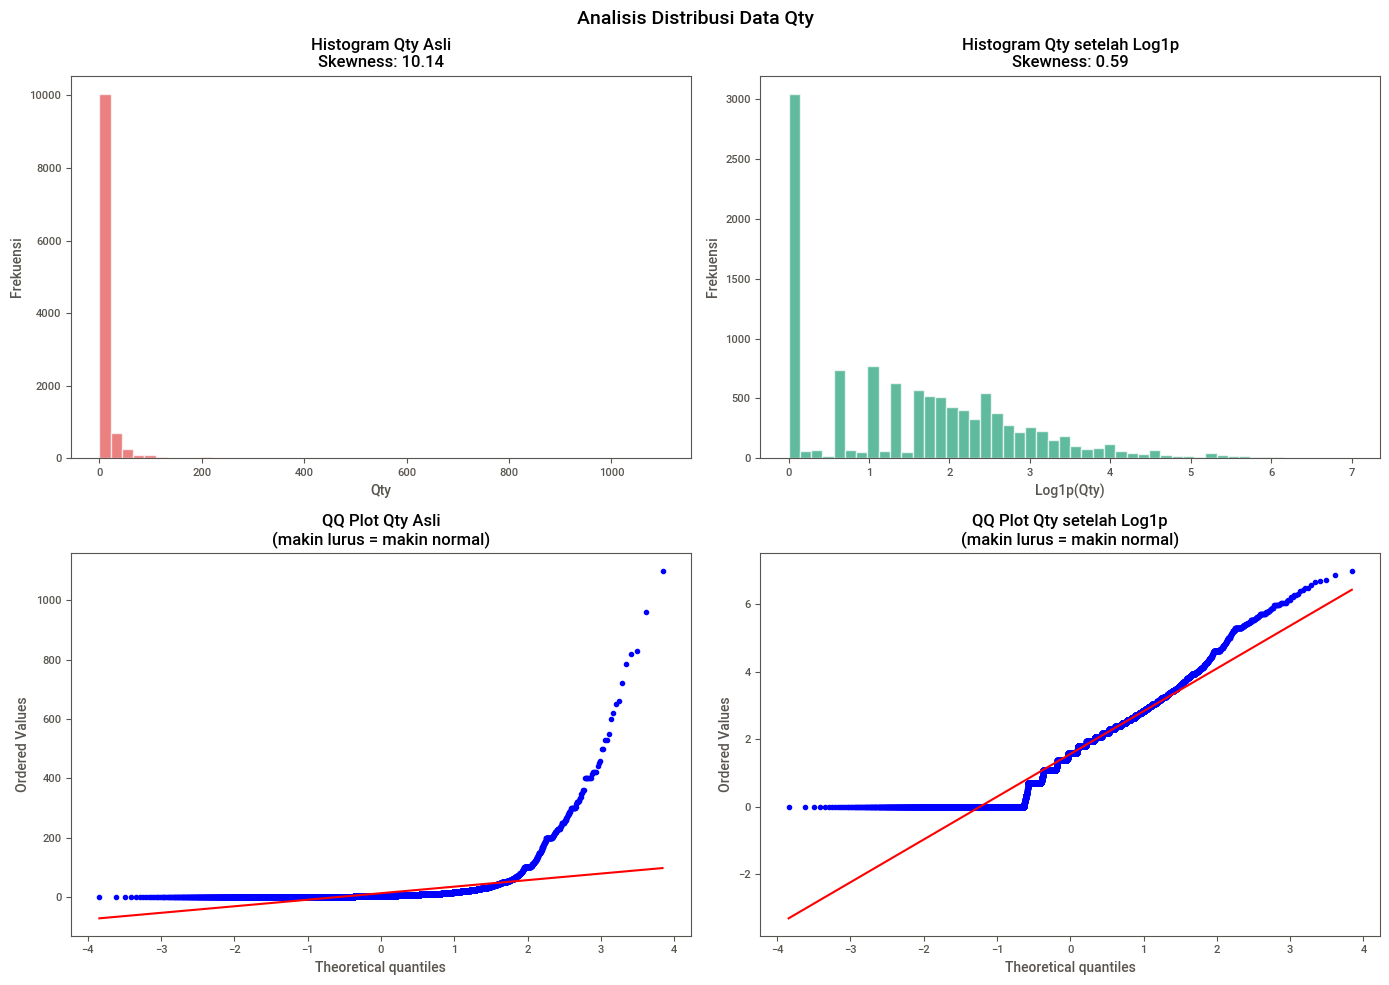

Metrik                        Asli    Log1p
Skewness                     10.14     0.59
Mean                         13.10     1.56
Std                          41.95     1.32
Proporsi nol (%)              26.4        -
Proporsi outlier (%)           9.6        -


In [45]:
def cek_distribusi(df, kolom='Qty'):
    
    data_raw = df[kolom].dropna()
    data_log = np.log1p(data_raw)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Analisis Distribusi Data Qty', fontsize=14, fontweight='bold')
    
    # 1. Histogram data asli
    axes[0, 0].hist(data_raw, bins=50, color='#E24B4A', alpha=0.7, edgecolor='white')
    axes[0, 0].set_title(f'Histogram Qty Asli\nSkewness: {data_raw.skew():.2f}')
    axes[0, 0].set_xlabel('Qty')
    axes[0, 0].set_ylabel('Frekuensi')
    
    # 2. Histogram setelah log1p
    axes[0, 1].hist(data_log, bins=50, color='#1D9E75', alpha=0.7, edgecolor='white')
    axes[0, 1].set_title(f'Histogram Qty setelah Log1p\nSkewness: {data_log.skew():.2f}')
    axes[0, 1].set_xlabel('Log1p(Qty)')
    axes[0, 1].set_ylabel('Frekuensi')
    
    # 3. QQ Plot data asli
    stats.probplot(data_raw, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ Plot Qty Asli\n(makin lurus = makin normal)')
    
    # 4. QQ Plot setelah log1p
    stats.probplot(data_log, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('QQ Plot Qty setelah Log1p\n(makin lurus = makin normal)')
    
    plt.tight_layout()
    plt.savefig('distribusi_qty.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Ringkasan statistik
    print("=" * 45)
    print(f"{'Metrik':<25} {'Asli':>8} {'Log1p':>8}")
    print("=" * 45)
    print(f"{'Skewness':<25} {data_raw.skew():>8.2f} {data_log.skew():>8.2f}")
    print(f"{'Mean':<25} {data_raw.mean():>8.2f} {data_log.mean():>8.2f}")
    print(f"{'Std':<25} {data_raw.std():>8.2f} {data_log.std():>8.2f}")
    print(f"{'Proporsi nol (%)':<25} {(data_raw==0).mean()*100:>8.1f} {'-':>8}")
    Q1, Q3 = data_raw.quantile(0.25), data_raw.quantile(0.75)
    IQR = Q3 - Q1
    outlier_pct = ((data_raw > Q3 + 1.5*IQR)).mean() * 100
    print(f"{'Proporsi outlier (%)':<25} {outlier_pct:>8.1f} {'-':>8}")
    print("=" * 45)

cek_distribusi(df_model, kolom='Qty')

# 6. Klasifikasi ADI-CV2

In [46]:
LEAD_TIME = 2      # asumsi lead time dalam minggu (untuk kolom Safety_Stock & Reorder_Point)
Z_SCORE   = 1.65   # service level 95% (Smooth & Erratic)

def adi_cv2(group):

    total_weeks  = len(group)
    active       = group[group["Qty"] > 0]
    active_weeks = len(active)
    zero_weeks   = total_weeks - active_weeks

    if active_weeks == 0:
        return pd.Series({
            "Kategori": "Never Sold", "Total_Weeks": total_weeks,
            "Active_Weeks": 0, "Zero_Weeks": zero_weeks,
            "Zero_Pct": 100, "ADI": np.inf,
            "Mean_Demand": 0, "Std_Demand": 0, "CV2": np.nan,
            "Safety_Stock": 0, "SS_Method": "Tidak dihitung (tidak pernah terjual)",
            "Safety_Stock_1Minggu": 0, "SS_1Minggu_Method": "Tidak dihitung (tidak pernah terjual)",
            "Reorder_Point": 0, "Reorder_Point_1Minggu": 0
        })

    adi         = total_weeks / active_weeks
    demand      = active["Qty"]
    mean_demand = demand.mean()
    std_demand  = demand.std(ddof=1) if active_weeks > 1 else 0
    cv2         = (std_demand / mean_demand) ** 2 if mean_demand > 0 else 0

    if adi < 1.32 and cv2 < 0.49:
        kategori = "Smooth"
    elif adi < 1.32:
        kategori = "Erratic"
    elif cv2 < 0.49:
        kategori = "Intermittent"
    else:
        kategori = "Lumpy"

    # Urutkan berdasarkan tanggal
    group_sorted = group.sort_values("Tanggal Transaksi")
    qty_series   = group_sorted["Qty"]  # seluruh histori mingguan, termasuk nol

    # ============================================================
    # SAFETY STOCK — berdasarkan LEAD TIME (mis. 2 minggu)
    # ============================================================
    if kategori in ["Smooth", "Erratic"]:
        std_all = qty_series.std(ddof=1)
        safety_stock = Z_SCORE * std_all * np.sqrt(LEAD_TIME)
        ss_method = f"Parametrik (Z={Z_SCORE} x sigma x akar({LEAD_TIME}))"
    else:
        rolling_demand = qty_series.rolling(window=LEAD_TIME).sum().dropna()
        if len(rolling_demand) == 0:
            safety_stock = 0
            ss_method = "Tidak dapat dihitung (data historis kurang dari lead time)"
        else:
            pct = 90 if len(rolling_demand) < 20 else 95
            safety_stock = np.percentile(rolling_demand, pct)
            ss_method = f"Non-parametrik (P{pct} agregat {LEAD_TIME} minggu, n={len(rolling_demand)})"

    # ============================================================
    # SAFETY STOCK — interpretasi PER 1 MINGGU (tanpa lead time)
    # ============================================================
    if kategori in ["Smooth", "Erratic"]:
        std_all = qty_series.std(ddof=1)
        safety_stock_1w = Z_SCORE * std_all  # sqrt(1) = 1, jadi dihilangkan
        ss_1w_method = f"Parametrik (Z={Z_SCORE} x sigma, per 1 minggu)"
    else:
        if len(qty_series) == 0:
            safety_stock_1w = 0
            ss_1w_method = "Tidak dapat dihitung"
        else:
            pct = 90 if len(qty_series) < 20 else 95
            safety_stock_1w = np.percentile(qty_series, pct)
            ss_1w_method = f"Non-parametrik (P{pct} mingguan, n={len(qty_series)})"

    # ============================================================
    # REORDER POINT (ROP)
    # ROP = (rata-rata demand per minggu x lead time) + safety stock
    # ============================================================
    reorder_point         = (mean_demand * LEAD_TIME) + safety_stock
    reorder_point_1minggu = (mean_demand * 1) + safety_stock_1w

    return pd.Series({
        "Kategori": kategori, "Total_Weeks": total_weeks,
        "Active_Weeks": active_weeks, "Zero_Weeks": zero_weeks,
        "Zero_Pct": round(zero_weeks / total_weeks * 100, 2),
        "ADI": round(adi, 4), "Mean_Demand": round(mean_demand, 2),
        "Std_Demand": round(std_demand, 2), "CV2": round(cv2, 4),
        "Safety_Stock": round(safety_stock, 2), "SS_Method": ss_method,
        "Safety_Stock_1Minggu": round(safety_stock_1w, 2), "SS_1Minggu_Method": ss_1w_method,
        "Reorder_Point": round(reorder_point, 2),
        "Reorder_Point_1Minggu": round(reorder_point_1minggu, 2)
    })

hasil_adi_cv2 = (
    df_model
    .groupby("Nama Barang")
    .apply(adi_cv2)
    .reset_index()
    .sort_values(["Kategori", "ADI", "CV2"])
)

hasil_adi_cv2

,Nama Barang,Kategori,Total_Weeks,Active_Weeks,Zero_Weeks,Zero_Pct,ADI,Mean_Demand,Std_Demand,CV2,Safety_Stock,SS_Method,Safety_Stock_1Minggu,SS_1Minggu_Method,Reorder_Point,Reorder_Point_1Minggu
126,SEDOTAN POP ICE,Erratic,79,78,1,1.27,1.0128,4.86,3.65,0.5641,8.56,Parametrik (Z=1.65 x sigma x akar(2)),6.05,"Parametrik (Z=1.65 x sigma, per 1 minggu)",18.27,10.91
116,PE CLIP C-TIK - 5 X 8,Erratic,79,78,1,1.27,1.0128,17.56,13.61,0.6003,31.89,Parametrik (Z=1.65 x sigma x akar(2)),22.55,"Parametrik (Z=1.65 x sigma, per 1 minggu)",67.01,40.11
108,PE 55 - 10 X 20,Erratic,79,78,1,1.27,1.0128,10.49,9.21,0.7715,21.53,Parametrik (Z=1.65 x sigma x akar(2)),15.23,"Parametrik (Z=1.65 x sigma, per 1 minggu)",42.51,25.71
98,NESTO PAPER BOWL 650 ML,Erratic,79,77,2,2.53,1.0260,17.91,12.54,0.4906,29.64,Parametrik (Z=1.65 x sigma x akar(2)),20.96,"Parametrik (Z=1.65 x sigma, per 1 minggu)",65.46,38.87
58,KARET SMILE - KUNING,Erratic,79,77,2,2.53,1.0260,5.84,4.49,0.5895,10.56,Parametrik (Z=1.65 x sigma x akar(2)),7.47,"Parametrik (Z=1.65 x sigma, per 1 minggu)",22.25,13.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,SEDOTAN STERIL LANCIP ISI 500 PCS,Smooth,79,64,15,18.99,1.2344,2.38,1.54,0.4193,3.90,Parametrik (Z=1.65 x sigma x akar(2)),2.76,"Parametrik (Z=1.65 x sigma, per 1 minggu)",8.65,5.13
53,HD TROYA 24,Smooth,79,63,16,20.25,1.2540,7.87,4.68,0.3531,12.24,Parametrik (Z=1.65 x sigma x akar(2)),8.66,"Parametrik (Z=1.65 x sigma, per 1 minggu)",27.99,16.53
52,HD TROYA 15,Smooth,79,62,17,21.52,1.2742,15.42,6.43,0.1741,19.94,Parametrik (Z=1.65 x sigma x akar(2)),14.10,"Parametrik (Z=1.65 x sigma, per 1 minggu)",50.78,29.52
70,KOTAK LEZAT ENAK 12 X 16,Smooth,79,61,18,22.78,1.2951,1.96,0.94,0.2284,2.73,Parametrik (Z=1.65 x sigma x akar(2)),1.93,"Parametrik (Z=1.65 x sigma, per 1 minggu)",6.65,3.89


In [47]:
hasil_adi_cv2.to_csv("hasil_adi_cv2_upd.csv")

#### Produk Smooth Demand

In [48]:
# Produk Smooth Demand
# (Permintaan terjadi secara rutin dengan jumlah penjualan yang relatif stabil)

display(
        pd.DataFrame(
            hasil_adi_cv2[
                hasil_adi_cv2['Kategori'] == "Smooth"
            ]['Nama Barang']
            .sort_values()
            .reset_index(drop=True)
        )
        .reset_index(names='No')
        .assign(No=lambda x: x['No'] + 1)
    )

,No,Nama Barang
0,1,BOTOL ALMOND 250ML
1,2,CUP JAXINE 55/60 ML
2,3,DM RECT 750 ML
3,4,EURO GOURMET EXTRA PEDAS 1 KG
4,5,FOAM KCS 2
5,6,FOAM KCS 3
6,7,GELAS SLIM 'TEN-TEN' 18 OZ
7,8,GELAS TECHNO 10 OZ
8,9,GELAS TECHNO 12 OZ
9,10,GELAS TECHNO 14 OZ


#### Produk Erratic Demand

In [49]:
# Produk Erratic Demand
# (Permintaan terjadi secara rutin, tetapi jumlah penjualannya berfluktuasi tinggi)

display(
        pd.DataFrame(
            hasil_adi_cv2[
                hasil_adi_cv2['Kategori'] == "Erratic"
            ]['Nama Barang']
            .sort_values()
            .reset_index(drop=True)
        )
        .reset_index(names='No')
        .assign(No=lambda x: x['No'] + 1)
    )

,No,Nama Barang
0,1,DM RECT 1000 ML
1,2,DM RECT 500 ML
2,3,DM RECT 650 ML
3,4,DM SQ 3000 ML
4,5,FOAM KCS 1
5,6,GELAS SLIM 'TEN-TEN' 22 OZ
6,7,GELAS TECHNO 16 OZ
7,8,HD AWUR 17
8,9,HD KALONG 35
9,10,HD KALONG 40


#### Produk Intermittent Demand

In [50]:
# Produk Intermittent Demand
# (Permintaan terjadi secara tidak rutin, namun jumlah penjualannya relatif stabil)

display(
        pd.DataFrame(
            hasil_adi_cv2[
                hasil_adi_cv2['Kategori'] == "Intermittent"
            ]['Nama Barang']
            .sort_values()
            .reset_index(drop=True)
        )
        .reset_index(names='No')
        .assign(No=lambda x: x['No'] + 1)
    )

,No,Nama Barang
0,1,CREAMER NDC DONGXIAO
1,2,DAIRY CROWN SKM 500 GR
2,3,DELMONTE TOMATO STANDING POUCH 1 KG
3,4,GELAS TENTEN 18 OZ
4,5,GELAS UNIVERSAL 14 OZ
5,6,GELAS UNIVERSAL 18 OZ - DATAR
6,7,HD FAMILY 28 - PUTIH SUSU
7,8,HD LOS BENING 15 - 8 ONS
8,9,HD LOS BENING 15 - 9 ONS
9,10,HD LOS BENING 24 - 8 ONS


#### Produk Lumpy Demand

In [51]:
# Produk Lumpy Demand
# (Permintaan terjadi secara tidak rutin dan jumlah penjualannya berfluktuasi tinggi)

display(
        pd.DataFrame(
            hasil_adi_cv2[
                hasil_adi_cv2['Kategori'] == "Intermittent"
            ]['Nama Barang']
            .sort_values()
            .reset_index(drop=True)
        )
        .reset_index(names='No')
        .assign(No=lambda x: x['No'] + 1)
    )

,No,Nama Barang
0,1,CREAMER NDC DONGXIAO
1,2,DAIRY CROWN SKM 500 GR
2,3,DELMONTE TOMATO STANDING POUCH 1 KG
3,4,GELAS TENTEN 18 OZ
4,5,GELAS UNIVERSAL 14 OZ
5,6,GELAS UNIVERSAL 18 OZ - DATAR
6,7,HD FAMILY 28 - PUTIH SUSU
7,8,HD LOS BENING 15 - 8 ONS
8,9,HD LOS BENING 15 - 9 ONS
9,10,HD LOS BENING 24 - 8 ONS


#### Proporsi Produk Berdasarkan Kategori Demand

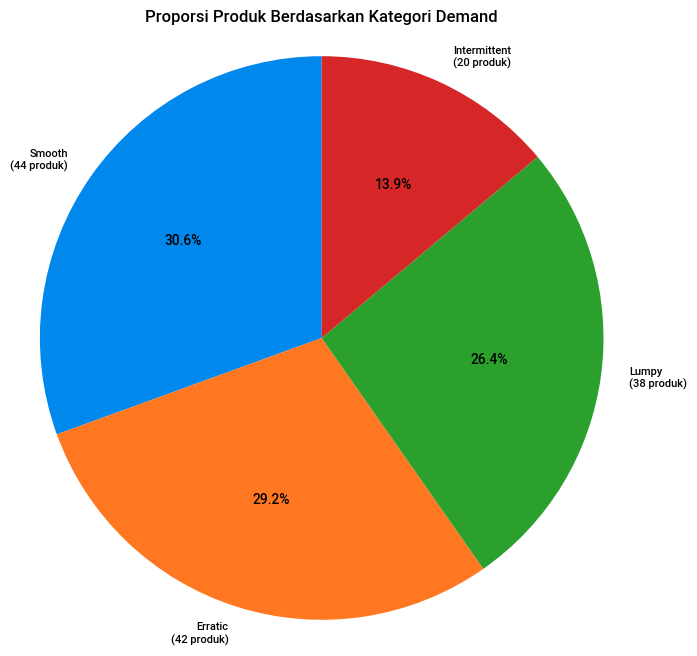

In [52]:
proporsi = hasil_adi_cv2['Kategori'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    proporsi,
    labels=[f"{k}\n({v} produk)" for k, v in zip(proporsi.index, proporsi.values)],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporsi Produk Berdasarkan Kategori Demand')
plt.axis('equal')
plt.show()

# 7. Feature Creation

In [53]:
def feature_creation(df_model: pd.DataFrame) -> pd.DataFrame:

    df = df_model.copy()
    df["Tanggal Transaksi"] = pd.to_datetime(df["Tanggal Transaksi"])
    df = df.sort_values(["Nama Barang", "Tanggal Transaksi"]).reset_index(drop=True)

    df["ID_Barang"] = df["Nama Barang"].astype("category").cat.codes

    df["Bulan"]             = df["Tanggal Transaksi"].dt.month
    df["Tahun"]             = df["Tanggal Transaksi"].dt.year
    df["Minggu_dalam_Tahun"] = df["Tanggal Transaksi"].dt.isocalendar().week.astype(int)
    df["Minggu_dalam_Bulan"] = (df["Tanggal Transaksi"].dt.day - 1) // 7 + 1

    for lag in [1, 2, 3, 4, 8, 12]:
        df[f"Lag_{lag}_Minggu"] = df.groupby("Nama Barang")["Qty"].shift(lag)

    for w in [4, 8, 12]:
        grp = df.groupby("Nama Barang")["Qty"]
        df[f"Avg_{w}_Minggu"]    = grp.transform(lambda x: x.shift(1).rolling(w).mean())
        df[f"Std_{w}_Minggu"]    = grp.transform(lambda x: x.shift(1).rolling(w).std())
        df[f"Max_{w}_Minggu"]    = grp.transform(lambda x: x.shift(1).rolling(w).max())
        df[f"Min_{w}_Minggu"]    = grp.transform(lambda x: x.shift(1).rolling(w).min())
        df[f"Median_{w}_Minggu"] = grp.transform(lambda x: x.shift(1).rolling(w).median())
        

    df = df.sort_values(["Tanggal Transaksi","Nama Barang"]).reset_index(drop=True)

    df = df.fillna(0).reset_index(drop=True)

    return df

df_model = feature_creation(df_model)

# 8. Feature Selection 

#### Heatmap Korelasi Fitur

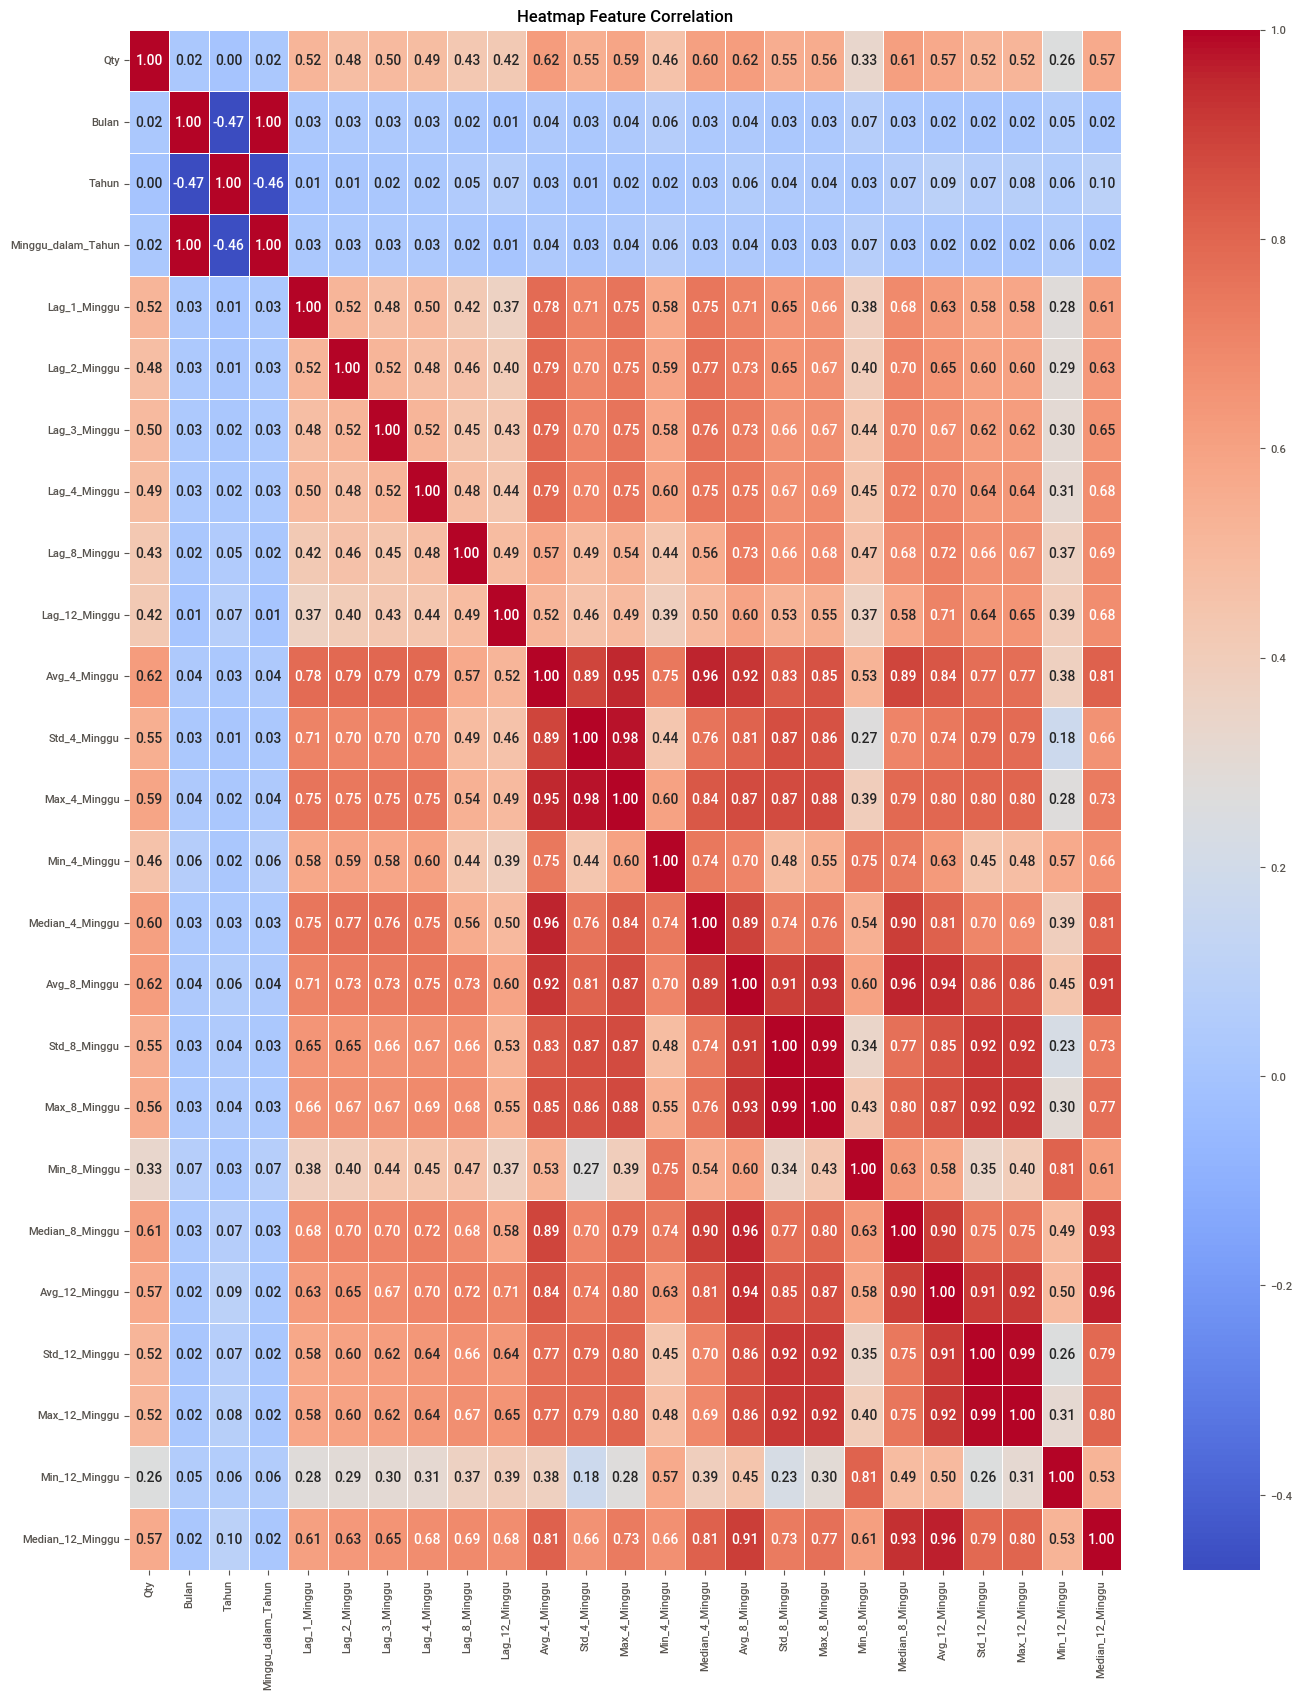

In [54]:
df_corr = df_model.select_dtypes(include=["int64", "int32", "float64"])
corr_matrix = df_corr.corr()

plt.figure(figsize=(16,20))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Heatmap Feature Correlation")
plt.show()

df_model['ID_Barang'] = df_model['ID_Barang'].astype(int)


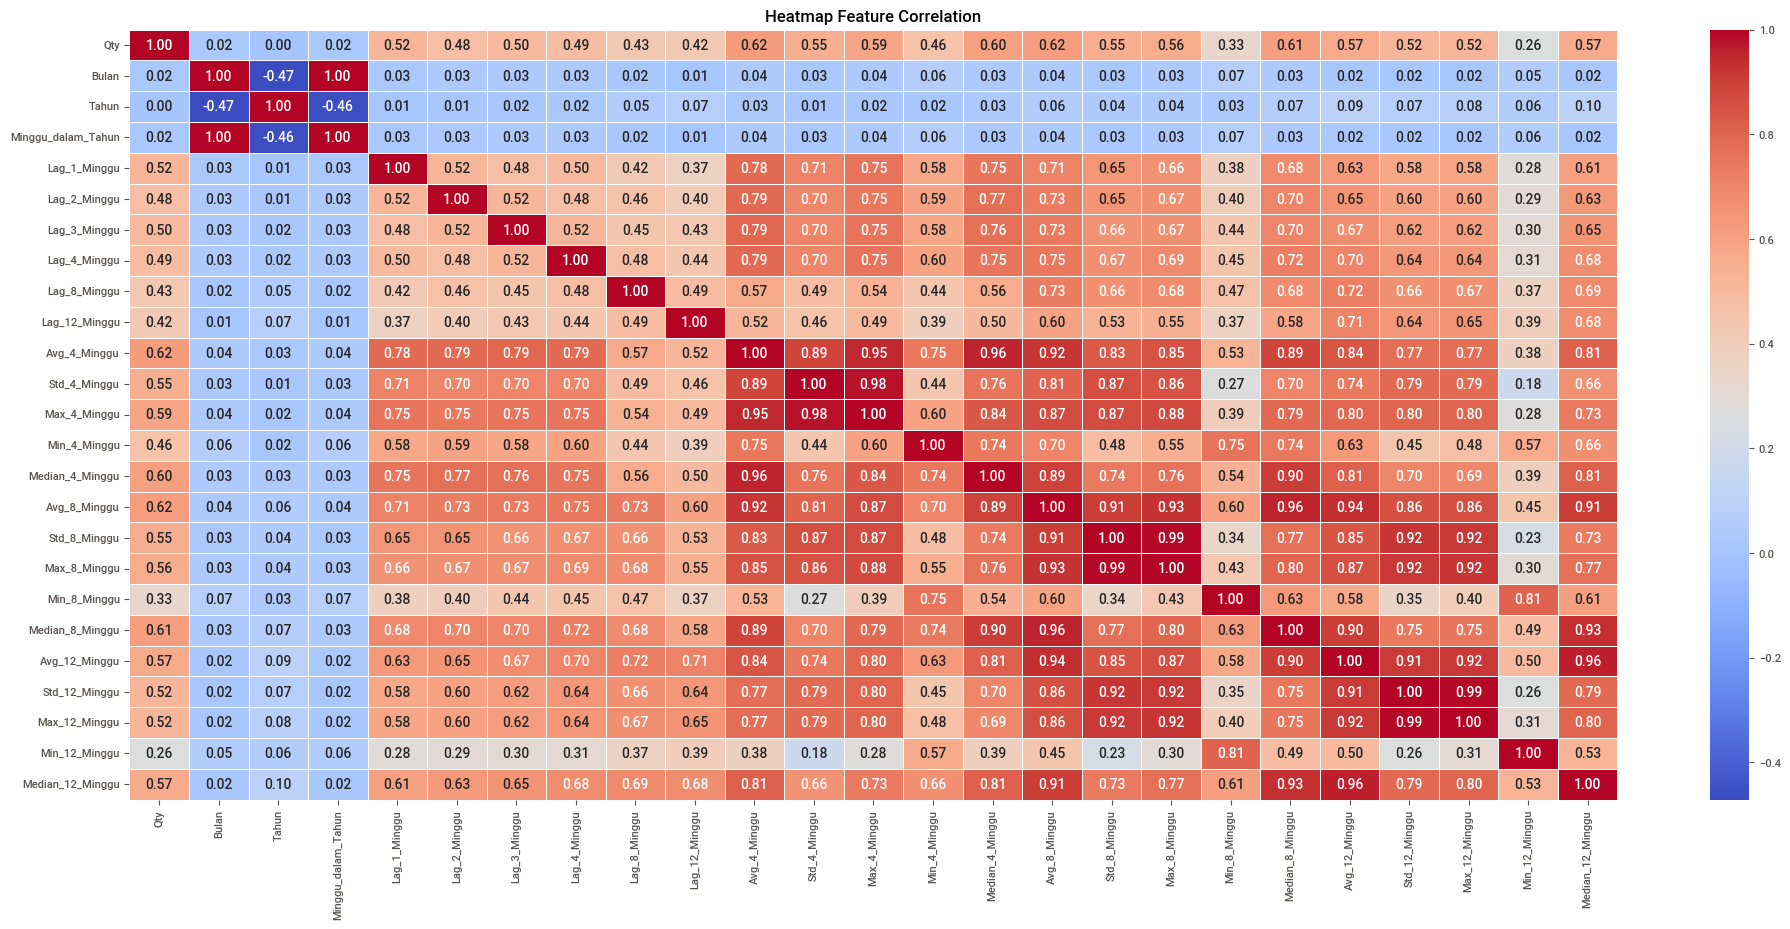

In [119]:
plt.figure(figsize=(24,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Feature Correlation")
plt.show()

#### Nilai Korelasi Fitur dengan Fitur Target

In [55]:
corr_target = corr_matrix["Qty"].sort_values(ascending=False)

print(corr_target)

Qty                   1.000000
Avg_4_Minggu          0.623872
Avg_8_Minggu          0.618338
Median_8_Minggu       0.612541
Median_4_Minggu       0.604127
Max_4_Minggu          0.590541
Avg_12_Minggu         0.573975
Median_12_Minggu      0.568082
Max_8_Minggu          0.561795
Std_8_Minggu          0.551801
Std_4_Minggu          0.549804
Lag_1_Minggu          0.521907
Max_12_Minggu         0.519430
Std_12_Minggu         0.517375
Lag_3_Minggu          0.497997
Lag_4_Minggu          0.485576
Lag_2_Minggu          0.478750
Min_4_Minggu          0.458233
Lag_8_Minggu          0.426310
Lag_12_Minggu         0.420705
Min_8_Minggu          0.328515
Min_12_Minggu         0.260017
Bulan                 0.023633
Minggu_dalam_Tahun    0.023591
Tahun                 0.003245
Name: Qty, dtype: float64


In [56]:
features = [
"Tahun",
"Bulan",
"Minggu_dalam_Bulan",
"Minggu_dalam_Tahun",

"Lag_1_Minggu",
"Lag_2_Minggu",
"Lag_3_Minggu",
"Lag_4_Minggu",
"Lag_8_Minggu",
"Lag_12_Minggu",

"Avg_4_Minggu",
"Avg_8_Minggu",
"Avg_12_Minggu",

"Std_4_Minggu",
"Std_8_Minggu",
"Std_12_Minggu",

"Max_4_Minggu",
"Max_8_Minggu",
"Max_12_Minggu",

"Min_4_Minggu",
"Min_8_Minggu",
"Min_12_Minggu",

"Median_4_Minggu",
"Median_8_Minggu",
"Median_12_Minggu",
]

target = "Qty"

# 9. Data Splitting

### a. Split Produk Smooth Demand 

In [57]:
produk_smooth = hasil_adi_cv2.loc[
    hasil_adi_cv2['Kategori'] == 'Smooth',
    'Nama Barang'
].sort_values()

df_model_smooth = (
    df_model[
        df_model['Nama Barang'].isin(produk_smooth)
    ]
    .sort_values(['Nama Barang', 'Tanggal Transaksi'])
    .reset_index(drop=True)
)

In [58]:
report = sv.analyze(df_model_smooth)
#report.show_html("report_data_smooth.html")

                                             |          | [  0%]   00:00 -> (? left)

### b. Split Produk Erratic Demand 

In [59]:
produk_erratic = hasil_adi_cv2.loc[
    hasil_adi_cv2['Kategori'] == 'Erratic',
    'Nama Barang'
].sort_values()

df_model_erratic = (
    df_model[
        df_model['Nama Barang'].isin(produk_erratic)
    ]
    .sort_values(['Nama Barang', 'Tanggal Transaksi'])
    .reset_index(drop=True)
)

In [60]:
report = sv.analyze(df_model_erratic)
#report.show_html("report_data_erratic.html")

                                             |          | [  0%]   00:00 -> (? left)

### c. Split Produk Intermittent Demand 

In [61]:
produk_intermittent = hasil_adi_cv2.loc[
    hasil_adi_cv2['Kategori'] == 'Intermittent',
    'Nama Barang'
].sort_values()

df_model_intermittent = (
    df_model[
        df_model['Nama Barang'].isin(produk_intermittent)
    ]
    .sort_values(['Nama Barang', 'Tanggal Transaksi'])
    .reset_index(drop=True)
)

df_model_intermittent

,Tanggal Transaksi,Nama Barang,Satuan,Qty,ID_Barang,Bulan,Tahun,Minggu_dalam_Tahun,Minggu_dalam_Bulan,Lag_1_Minggu,...,Avg_8_Minggu,Std_8_Minggu,Max_8_Minggu,Min_8_Minggu,Median_8_Minggu,Avg_12_Minggu,Std_12_Minggu,Max_12_Minggu,Min_12_Minggu,Median_12_Minggu
0,2024-07-07,CREAMER NDC DONGXIAO,KG,0.0,3,7,2024,27,1,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
1,2024-07-14,CREAMER NDC DONGXIAO,KG,0.0,3,7,2024,28,2,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
2,2024-07-21,CREAMER NDC DONGXIAO,KG,0.0,3,7,2024,29,3,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
3,2024-07-28,CREAMER NDC DONGXIAO,KG,0.0,3,7,2024,30,4,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
4,2024-08-04,CREAMER NDC DONGXIAO,KG,0.0,3,8,2024,31,1,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,2025-12-07,TALI RAFIA MG BIRU,ROLL,4.0,137,12,2025,49,1,0.0,...,21.750,12.383745,34.0,0.0,25.5,17.000000,13.107943,34.0,0.0,16.5
1576,2025-12-14,TALI RAFIA MG BIRU,ROLL,0.0,137,12,2025,50,2,4.0,...,18.500,13.288018,34.0,0.0,17.0,17.333333,12.680216,34.0,0.0,16.5
1577,2025-12-21,TALI RAFIA MG BIRU,ROLL,0.0,137,12,2025,51,3,0.0,...,16.875,14.769055,34.0,0.0,16.5,17.333333,12.680216,34.0,0.0,16.5
1578,2025-12-28,TALI RAFIA MG BIRU,ROLL,2.0,137,12,2025,52,4,0.0,...,12.625,14.009563,32.0,0.0,8.0,15.666667,13.580289,34.0,0.0,12.5


In [62]:
report = sv.analyze(df_model_intermittent)
#report.show_html("report_data_intermittent.html")

                                             |          | [  0%]   00:00 -> (? left)

### d. Split Produk Lumpy Demand 

In [63]:
produk_lumpy = hasil_adi_cv2.loc[
    hasil_adi_cv2['Kategori'] == 'Lumpy',
    'Nama Barang'
].sort_values()

df_model_lumpy = (
    df_model[
        df_model['Nama Barang'].isin(produk_lumpy)
    ]
    .sort_values(['Nama Barang', 'Tanggal Transaksi'])
    .reset_index(drop=True)
)

df_model_lumpy

,Tanggal Transaksi,Nama Barang,Satuan,Qty,ID_Barang,Bulan,Tahun,Minggu_dalam_Tahun,Minggu_dalam_Bulan,Lag_1_Minggu,...,Avg_8_Minggu,Std_8_Minggu,Max_8_Minggu,Min_8_Minggu,Median_8_Minggu,Avg_12_Minggu,Std_12_Minggu,Max_12_Minggu,Min_12_Minggu,Median_12_Minggu
0,2024-07-07,BESEK,KODI,0.0,0,7,2024,27,1,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
1,2024-07-14,BESEK,KODI,0.0,0,7,2024,28,2,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
2,2024-07-21,BESEK,KODI,0.0,0,7,2024,29,3,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
3,2024-07-28,BESEK,KODI,0.0,0,7,2024,30,4,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
4,2024-08-04,BESEK,KODI,2.0,0,8,2024,31,1,0.0,...,0.000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2997,2025-12-07,TOPLES TABUNG 800 ML - TEBAL,PCS,12.0,140,12,2025,49,1,29.0,...,5.000,9.899495,29.0,0.0,1.0,4.166667,8.408149,29.0,0.0,0.0
2998,2025-12-14,TOPLES TABUNG 800 ML - TEBAL,PCS,15.0,140,12,2025,50,2,12.0,...,5.875,10.204166,29.0,0.0,1.0,5.166667,8.579397,29.0,0.0,1.0
2999,2025-12-21,TOPLES TABUNG 800 ML - TEBAL,PCS,41.0,140,12,2025,51,3,15.0,...,7.750,10.347532,29.0,0.0,3.0,5.583333,8.948929,29.0,0.0,1.0
3000,2025-12-28,TOPLES TABUNG 800 ML - TEBAL,PCS,52.0,140,12,2025,52,4,41.0,...,12.875,15.046950,41.0,0.0,8.0,9.000000,13.362090,41.0,0.0,3.0


In [64]:
report = sv.analyze(df_model_lumpy)
#report.show_html("report_data_lumpy.html")

                                             |          | [  0%]   00:00 -> (? left)

### e. Train-Test Split (70:15:15) berdasarkan Tanggal Transaksi

In [65]:
def split_data_70_15_15(df, date_col="Tanggal Transaksi",
                         train_ratio=0.70, val_ratio=0.15):
    
    unique_dates  = sorted(df[date_col].unique())
    n_dates       = len(unique_dates)

    n_train_dates = max(1, round(n_dates * train_ratio))
    n_val_dates   = max(1, round(n_dates * val_ratio))
    n_test_dates  = n_dates - n_train_dates - n_val_dates

    cutoff_train  = unique_dates[n_train_dates - 1]
    cutoff_val    = unique_dates[n_train_dates + n_val_dates - 1]
    test_start    = unique_dates[n_train_dates + n_val_dates]

    train = df[df[date_col] <= cutoff_train]
    val   = df[(df[date_col] > cutoff_train) & (df[date_col] <= cutoff_val)]
    test  = df[df[date_col] > cutoff_val]

    print("=== Split 70 : 15 : 15 ===")
    print(f"Total tanggal unik  : {n_dates}")
    print(f"Train : {n_train_dates} minggu ({n_train_dates/n_dates*100:.0f}%) | s/d {cutoff_train} | {len(train)} baris")
    print(f"Val   : {n_val_dates} minggu ({n_val_dates/n_dates*100:.0f}%) | s/d {cutoff_val}  | {len(val)} baris")
    print(f"Test  : {n_test_dates} minggu ({n_test_dates/n_dates*100:.0f}%) | dari {test_start}  | {len(test)} baris")

    return train, val, test

In [66]:
train_all, val_all, test_all = split_data_70_15_15(df_model, val_ratio=0.15)

=== Split 70 : 15 : 15 ===
Total tanggal unik  : 79
Train : 55 minggu (70%) | s/d 2025-07-20 00:00:00 | 7920 baris
Val   : 12 minggu (15%) | s/d 2025-10-12 00:00:00  | 1728 baris
Test  : 12 minggu (15%) | dari 2025-10-19 00:00:00  | 1728 baris


In [67]:
train_smooth, val_smooth, test_smooth = split_data_70_15_15(df_model_smooth, val_ratio=0.15)

=== Split 70 : 15 : 15 ===
Total tanggal unik  : 79
Train : 55 minggu (70%) | s/d 2025-07-20 00:00:00 | 2420 baris
Val   : 12 minggu (15%) | s/d 2025-10-12 00:00:00  | 528 baris
Test  : 12 minggu (15%) | dari 2025-10-19 00:00:00  | 528 baris


In [68]:
train_erratic, val_erratic, test_erratic = split_data_70_15_15(df_model_erratic, val_ratio=0.15)

=== Split 70 : 15 : 15 ===
Total tanggal unik  : 79
Train : 55 minggu (70%) | s/d 2025-07-20 00:00:00 | 2310 baris
Val   : 12 minggu (15%) | s/d 2025-10-12 00:00:00  | 504 baris
Test  : 12 minggu (15%) | dari 2025-10-19 00:00:00  | 504 baris


In [69]:
train_intermittent, val_intermittent, test_intermittent = split_data_70_15_15(df_model_intermittent, val_ratio=0.15)

=== Split 70 : 15 : 15 ===
Total tanggal unik  : 79
Train : 55 minggu (70%) | s/d 2025-07-20 00:00:00 | 1100 baris
Val   : 12 minggu (15%) | s/d 2025-10-12 00:00:00  | 240 baris
Test  : 12 minggu (15%) | dari 2025-10-19 00:00:00  | 240 baris


In [70]:
train_lumpy, val_lumpy, test_lumpy = split_data_70_15_15(df_model_lumpy, val_ratio=0.15)

=== Split 70 : 15 : 15 ===
Total tanggal unik  : 79
Train : 55 minggu (70%) | s/d 2025-07-20 00:00:00 | 2090 baris
Val   : 12 minggu (15%) | s/d 2025-10-12 00:00:00  | 456 baris
Test  : 12 minggu (15%) | dari 2025-10-19 00:00:00  | 456 baris


### f. Split Data Train X Y

In [71]:
X_train_all = train_all[features]
y_train_all = train_all[target]
X_val_all   = val_all[features]
y_val_all   = val_all[target]
X_test_all = test_all[features]
y_test_all = test_all[target]

X_train_smooth = train_smooth[features]
y_train_smooth = train_smooth[target]
X_val_smooth   = val_smooth[features]
y_val_smooth   = val_smooth[target]
X_test_smooth = test_smooth[features]
y_test_smooth = test_smooth[target]

X_train_erratic = train_erratic[features]
y_train_erratic = train_erratic[target]
X_val_erratic   = val_erratic[features]
y_val_erratic   = val_erratic[target]
X_test_erratic = test_erratic[features]
y_test_erratic = test_erratic[target]

X_train_intermittent = train_intermittent[features]
y_train_intermittent = train_intermittent[target]
X_val_intermittent   = val_intermittent[features]
y_val_intermittent   = val_intermittent[target]
X_test_intermittent = test_intermittent[features]
y_test_intermittent = test_intermittent[target]

X_train_lumpy = train_lumpy[features]
y_train_lumpy = train_lumpy[target]
X_val_lumpy   = val_lumpy[features]
y_val_lumpy   = val_lumpy[target]
X_test_lumpy = test_lumpy[features]
y_test_lumpy = test_lumpy[target]

# 10. Predict & Evaluation

## 9.1 XGBoost

### a. Predict

In [72]:
# Semua Produk
y_pred_all_xgb_train = xgb_all.predict(X_train_all)
y_pred_all_xgb_val   = xgb_all.predict(X_val_all)
y_pred_all_xgb_test  = xgb_all.predict(X_test_all)

# Produk Smooth Demand
y_pred_smooth_xgb_train = xgb_smooth.predict(X_train_smooth)
y_pred_smooth_xgb_val   = xgb_smooth.predict(X_val_smooth)
y_pred_smooth_xgb_test  = xgb_smooth.predict(X_test_smooth)

# Produk Erratic Demand
y_pred_erratic_xgb_train = xgb_erractic.predict(X_train_erratic)
y_pred_erratic_xgb_val   = xgb_erractic.predict(X_val_erratic)
y_pred_erratic_xgb_test  = xgb_erractic.predict(X_test_erratic)

# Produk Intermittent Demand 
y_pred_intermittent_xgb_train = xgb_intermittent.predict(X_train_intermittent)
y_pred_intermittent_xgb_val   = xgb_intermittent.predict(X_val_intermittent)
y_pred_intermittent_xgb_test  = xgb_intermittent.predict(X_test_intermittent)

# Produk Lumpy Demand
y_pred_lumpy_xgb_train = xgb_lumpy.predict(X_train_lumpy)
y_pred_lumpy_xgb_val   = xgb_lumpy.predict(X_val_lumpy)
y_pred_lumpy_xgb_test  = xgb_lumpy.predict(X_test_lumpy)

### b. Evaluation

#### MAE, R2, LOR

In [73]:
def evaluate_forecasting(
    y_train, y_pred_train,
    y_val, y_pred_val,
    y_test, y_pred_test,
    label
):

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_val   = mean_absolute_error(y_val, y_pred_val)
    mae_test  = mean_absolute_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_val   = r2_score(y_val, y_pred_val)
    r2_test  = r2_score(y_test, y_pred_test)

    gap_train_val  = ((mae_val - mae_train) / mae_train) * 100
    gap_train_test = ((mae_test - mae_train) / mae_train) * 100

    lor = np.log(mae_train / mae_test)

    if np.isclose(lor, 0, atol=0.05):
        status_lor = "Ideal"
    elif lor < 0:
        status_lor = "Overfitting"
    else:
        status_lor = "Underfitting"

    return {
        "Kategori Data": label,

        "MAE Train": round(mae_train, 2),
        "MAE Val": round(mae_val, 2),
        "MAE Test": round(mae_test, 2),

        "R2 Train": round(r2_train, 3),
        "R2 Val": round(r2_val, 3),
        "R2 Test": round(r2_test, 3),

        "Gap Train-Val (%)": round(gap_train_val, 2),
        "Gap Train-Test (%)": round(gap_train_test, 2),

        "LOR": round(lor, 3),
        "Status LOR": status_lor
    }

In [74]:
hasil_perbandingan_xgboost = pd.DataFrame([

    evaluate_forecasting(
        y_train_all, y_pred_all_xgb_train,
        y_val_all, y_pred_all_xgb_val,
        y_test_all, y_pred_all_xgb_test,
        "All Product"
    ),

    evaluate_forecasting(
        y_train_smooth, y_pred_smooth_xgb_train,
        y_val_smooth, y_pred_smooth_xgb_val,
        y_test_smooth, y_pred_smooth_xgb_test,
        "Smooth Demand"
    ),

    evaluate_forecasting(
        y_train_erratic, y_pred_erratic_xgb_train,
        y_val_erratic, y_pred_erratic_xgb_val,
        y_test_erratic, y_pred_erratic_xgb_test,
        "Erratic Demand"
    ),

    evaluate_forecasting(
        y_train_intermittent, y_pred_intermittent_xgb_train,
        y_val_intermittent, y_pred_intermittent_xgb_val,
        y_test_intermittent, y_pred_intermittent_xgb_test,
        "Intermittent Demand"
    ),

    evaluate_forecasting(
        y_train_lumpy, y_pred_lumpy_xgb_train,
        y_val_lumpy, y_pred_lumpy_xgb_val,
        y_test_lumpy, y_pred_lumpy_xgb_test,
        "Lumpy Demand"
    )

])

hasil_perbandingan_xgboost

,Kategori Data,MAE Train,MAE Val,MAE Test,R2 Train,R2 Val,R2 Test,Gap Train-Val (%),Gap Train-Test (%),LOR,Status LOR
0,All Product,8.16,8.74,10.28,0.377,0.476,0.300,7.17,26.05,-0.231,Overfitting
1,Smooth Demand,7.27,6.86,6.89,0.556,0.783,0.727,-5.57,-5.20,0.053,Underfitting
2,Erratic Demand,12.66,15.01,20.12,0.619,0.472,0.208,18.57,58.99,-0.464,Overfitting
3,Intermittent Demand,1.88,2.68,2.55,0.484,0.485,0.508,42.99,35.97,-0.307,Overfitting
4,Lumpy Demand,8.42,5.48,7.19,0.026,-0.041,-0.041,-35.00,-14.61,0.158,Underfitting


#### Data Aktual vs Prediksi

In [75]:
def compare_prediksi_aktual(
    y_true,
    y_pred,
    df_referensi,
    label="RESULT"
):

    # Ubah menjadi array 1 dimensi
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # Validasi jumlah data
    if len(y_true) != len(y_pred):
        raise ValueError("Jumlah y_true dan y_pred tidak sama.")

    if len(df_referensi) != len(y_true):
        raise ValueError("Jumlah baris df_referensi tidak sama dengan jumlah data prediksi.")

    # Membuat dataframe hasil
    hasil = (
        df_referensi[["Nama Barang", "Tanggal Transaksi"]]
        .copy()
        .reset_index(drop=True)
    )

    hasil["Qty_Aktual"] = y_true
    hasil["Qty_Prediksi"] = y_pred
    hasil["Selisih_Absolut"] = np.abs(
        hasil["Qty_Aktual"] - hasil["Qty_Prediksi"]
    )

    # =====================
    # MAE Keseluruhan
    # =====================
    mae_all = mean_absolute_error(
        hasil["Qty_Aktual"],
        hasil["Qty_Prediksi"]
    )

    # =====================
    # MAE Qty = 0
    # =====================
    zero_mask = hasil["Qty_Aktual"] == 0

    mae_zero = (
        mean_absolute_error(
            hasil.loc[zero_mask, "Qty_Aktual"],
            hasil.loc[zero_mask, "Qty_Prediksi"]
        )
        if zero_mask.any()
        else np.nan
    )

    # =====================
    # MAE Qty > 0
    # =====================
    nonzero_mask = hasil["Qty_Aktual"] > 0

    mae_nonzero = (
        mean_absolute_error(
            hasil.loc[nonzero_mask, "Qty_Aktual"],
            hasil.loc[nonzero_mask, "Qty_Prediksi"]
        )
        if nonzero_mask.any()
        else np.nan
    )

    print(f"\n===== {label} =====")
    print(f"MAE Keseluruhan      : {mae_all:.4f}")
    print(f"Proporsi Qty = 0     : {zero_mask.mean()*100:.2f}%")
    print(f"MAE Qty = 0          : {mae_zero:.4f}")
    print(f"MAE Qty > 0          : {mae_nonzero:.4f}")

    return hasil

In [76]:
hasil_smooth_xgb_train = compare_prediksi_aktual(
    y_train_smooth,
    y_pred_smooth_xgb_train,
    train_smooth,
    label="XGBoost - Smooth Demand (Train)"
)


===== XGBoost - Smooth Demand (Train) =====
MAE Keseluruhan      : 7.2692
Proporsi Qty = 0     : 9.13%
MAE Qty = 0          : 7.7537
MAE Qty > 0          : 7.2205


In [77]:
hasil_smooth_xgb_val = compare_prediksi_aktual(
    y_val_smooth,
    y_pred_smooth_xgb_val,
    val_smooth,
    label="XGBoost - Smooth Demand (Validation)"
)


===== XGBoost - Smooth Demand (Validation) =====
MAE Keseluruhan      : 6.8641
Proporsi Qty = 0     : 5.49%
MAE Qty = 0          : 7.4728
MAE Qty > 0          : 6.8288


In [78]:
hasil_smooth_xgb = compare_prediksi_aktual(
    y_test_smooth,
    y_pred_smooth_xgb_test,
    test_smooth,
    label="XGBoost - Smooth Demand (Test)"
)


===== XGBoost - Smooth Demand (Test) =====
MAE Keseluruhan      : 6.8911
Proporsi Qty = 0     : 8.71%
MAE Qty = 0          : 6.0864
MAE Qty > 0          : 6.9679


In [79]:
hasil_smooth_xgb

,Nama Barang,Tanggal Transaksi,Qty_Aktual,Qty_Prediksi,Selisih_Absolut
0,BOTOL ALMOND 250ML,2025-10-19,352.0,181.930664,170.069336
1,BOTOL ALMOND 250ML,2025-10-26,400.0,144.504547,255.495453
2,BOTOL ALMOND 250ML,2025-11-02,233.0,175.353897,57.646103
3,BOTOL ALMOND 250ML,2025-11-09,170.0,168.366791,1.633209
4,BOTOL ALMOND 250ML,2025-11-16,160.0,168.366791,8.366791
...,...,...,...,...,...
523,SENDOK MKN VICTORY - PUTIH SUSU,2025-12-07,4.0,4.990939,0.990939
524,SENDOK MKN VICTORY - PUTIH SUSU,2025-12-14,0.0,4.632051,4.632051
525,SENDOK MKN VICTORY - PUTIH SUSU,2025-12-21,0.0,3.534353,3.534353
526,SENDOK MKN VICTORY - PUTIH SUSU,2025-12-28,0.0,3.534353,3.534353


#### Analisis MAE per Produk

In [80]:
def analisis_per_produk(
    y_true,
    y_pred,
    df_referensi
):

    df = df_referensi[
        ["Nama Barang"]
    ].copy().reset_index(drop=True)

    df["Qty_Aktual"] = np.array(y_true).flatten()
    df["Qty_Prediksi"] = np.array(y_pred).flatten()

    df["Error"] = np.abs(
        df["Qty_Aktual"] -
        df["Qty_Prediksi"]
    )

    hasil = (
        df.groupby("Nama Barang")
        .agg(
            Min=("Qty_Aktual", "min"),
            Q1=("Qty_Aktual", lambda x: x.quantile(0.25)),
            Q2=("Qty_Aktual", "median"),
            Q3=("Qty_Aktual", lambda x: x.quantile(0.75)),
            Max=("Qty_Aktual", "max"),
            MAE=("Error", "mean")
        )
        .reset_index()
        .round(2)
    )

    return hasil.sort_values(
        "MAE",
        ascending=False
    )

In [81]:
error_produk_smooth_val = analisis_per_produk(
    y_val_smooth,
    y_pred_smooth_xgb_val,
    val_smooth
)

error_produk_smooth_val.sort_values("Nama Barang")

,Nama Barang,Min,Q1,Q2,Q3,Max,MAE
0,BOTOL ALMOND 250ML,100.00,200.00,212.50,351.25,460.00,85.43
1,CUP JAXINE 55/60 ML,8.00,9.00,11.50,15.25,19.00,3.76
2,DM RECT 750 ML,2.00,3.15,4.12,5.05,7.20,1.81
3,EURO GOURMET EXTRA PEDAS 1 KG,0.00,3.50,6.50,9.25,15.00,4.11
4,FOAM KCS 2,4.12,8.46,10.42,12.78,22.08,3.94
5,FOAM KCS 3,1.22,2.53,3.45,4.13,5.13,1.09
6,GELAS SLIM 'TEN-TEN' 18 OZ,0.00,30.50,46.00,53.75,86.00,23.94
7,GELAS TECHNO 10 OZ,9.00,14.00,16.00,18.00,29.00,5.84
8,GELAS TECHNO 12 OZ,3.00,6.00,7.50,10.25,13.00,3.21
9,GELAS TECHNO 14 OZ,0.00,22.75,35.00,41.50,51.00,16.97


In [82]:
error_produk_smooth_test = analisis_per_produk(
    y_test_smooth,
    y_pred_smooth_xgb_test,
    test_smooth
)

error_produk_smooth_test.sort_values("Nama Barang")

,Nama Barang,Min,Q1,Q2,Q3,Max,MAE
0,BOTOL ALMOND 250ML,115.00,182.75,231.50,322.00,420.00,101.38
1,CUP JAXINE 55/60 ML,2.00,6.00,8.50,11.75,22.00,5.20
2,DM RECT 750 ML,0.00,0.00,0.22,2.30,4.00,2.92
3,EURO GOURMET EXTRA PEDAS 1 KG,4.00,8.75,10.00,13.50,21.00,4.89
4,FOAM KCS 2,6.00,7.40,7.93,9.23,13.50,2.04
5,FOAM KCS 3,0.00,0.86,1.27,2.85,6.22,2.33
6,GELAS SLIM 'TEN-TEN' 18 OZ,0.00,13.75,36.50,57.25,70.00,17.56
7,GELAS TECHNO 10 OZ,0.00,6.00,9.00,13.25,27.00,5.73
8,GELAS TECHNO 12 OZ,3.00,8.75,10.50,12.25,17.00,3.63
9,GELAS TECHNO 14 OZ,6.00,18.00,28.00,37.50,61.00,9.10


In [83]:
def plot_prediksi_vs_aktual(
    y_true,
    y_pred,
    title="Prediksi vs Aktual"
):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(12,5))

    plt.plot(
        range(len(y_true)),
        y_true,
        label="Aktual",
        linewidth=2
    )

    plt.plot(
        range(len(y_pred)),
        y_pred,
        label="Prediksi",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Observasi")
    plt.ylabel("Qty")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

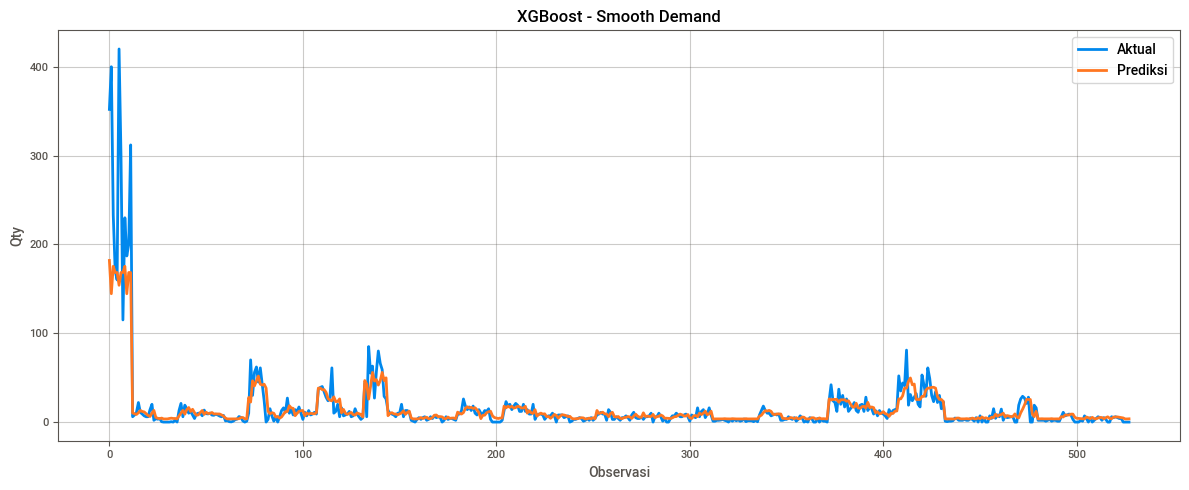

In [84]:
plot_prediksi_vs_aktual(
    y_test_smooth,
    y_pred_smooth_xgb_test,
    "XGBoost - Smooth Demand"
)

In [85]:
def data_per_produk(
    y_true,
    y_pred,
    df
):

    hasil = df.copy().reset_index(drop=True)

    hasil["Qty_Aktual"] = np.array(y_true).flatten()
    hasil["Qty_Prediksi"] = np.array(y_pred).flatten()

    return hasil

In [86]:
hasil_smooth = data_per_produk(
    y_test_smooth,
    y_pred_smooth_xgb_test,
    test_smooth
)

In [87]:
def plot_produk(
    data,
    nama_produk
):

    df_plot = (
        data[data["Nama Barang"] == nama_produk]
        .sort_values("Tanggal Transaksi")
    )

    plt.figure(figsize=(12,5))

    plt.plot(
        df_plot["Tanggal Transaksi"],
        df_plot["Qty_Aktual"],
        marker="o",
        linewidth=2,
        label="Aktual"
    )

    plt.plot(
        df_plot["Tanggal Transaksi"],
        df_plot["Qty_Prediksi"],
        marker="s",
        linewidth=2,
        label="Prediksi"
    )

    plt.title(nama_produk)

    plt.xlabel("Tanggal")
    plt.ylabel("Qty")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

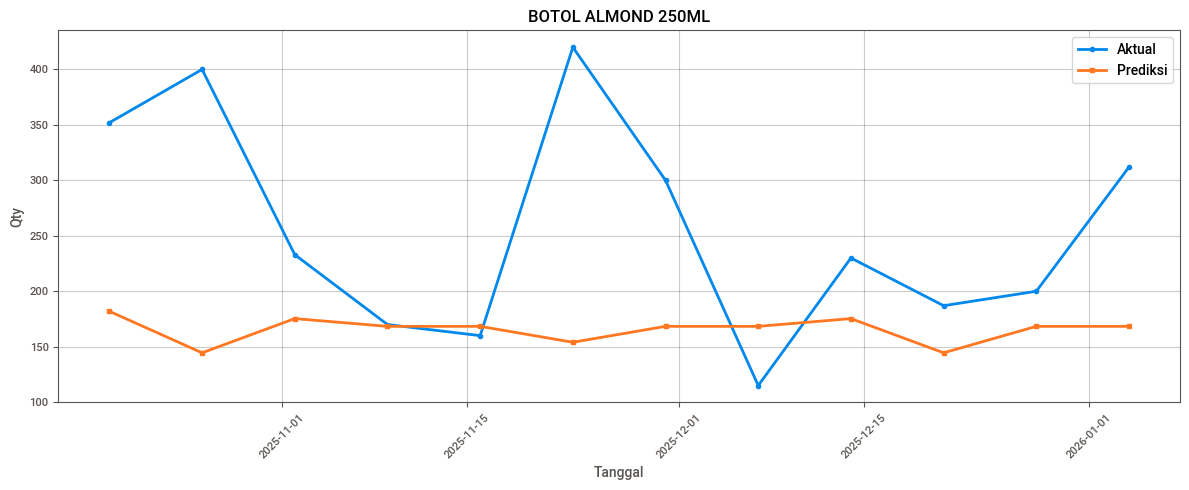

In [88]:
plot_produk(
    hasil_smooth,
    "BOTOL ALMOND 250ML"
)

### c. Feature Importance

In [89]:
def xgboost_feature_importance(
    model,
    feature_names,
    title="Feature Importance XGBoost",
    color="green"
):

    feature_importance = model.feature_importances_
    indices = np.argsort(feature_importance)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        range(len(feature_importance)),
        feature_importance[indices],
        color=color,
        align='center'
    )

    for bar, val in zip(bars, feature_importance[indices]):
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            ha='left', va='center',
            fontsize=8, fontweight='bold'
        )

    ax.set_yticks(range(len(feature_importance)))
    ax.set_yticklabels([feature_names[idx] for idx in indices])
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    return feature_importance

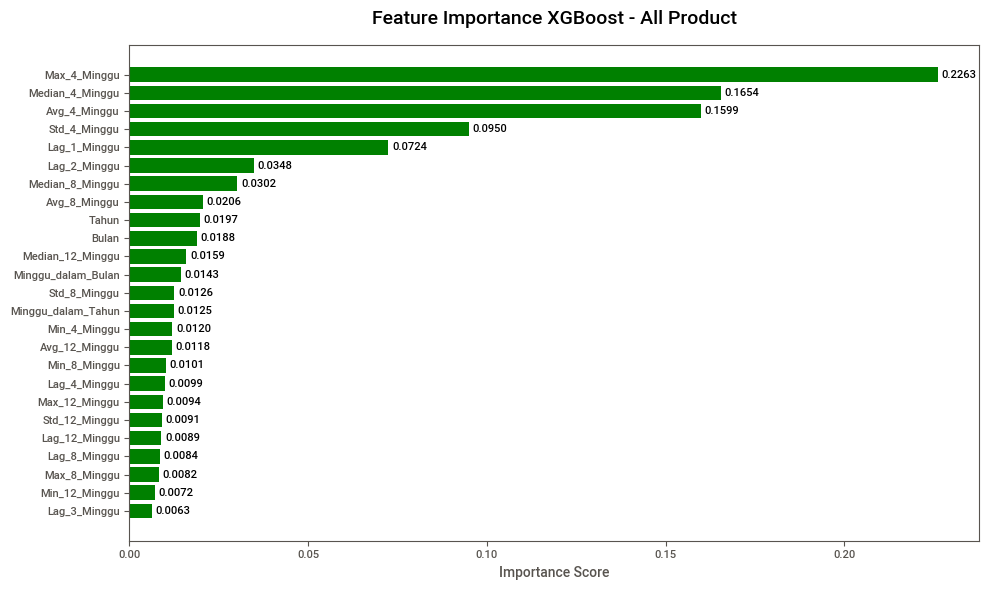

In [90]:
importance_all_xgb = xgboost_feature_importance(
    model=xgb_all,
    feature_names=features,
    title="Feature Importance XGBoost - All Product"
)

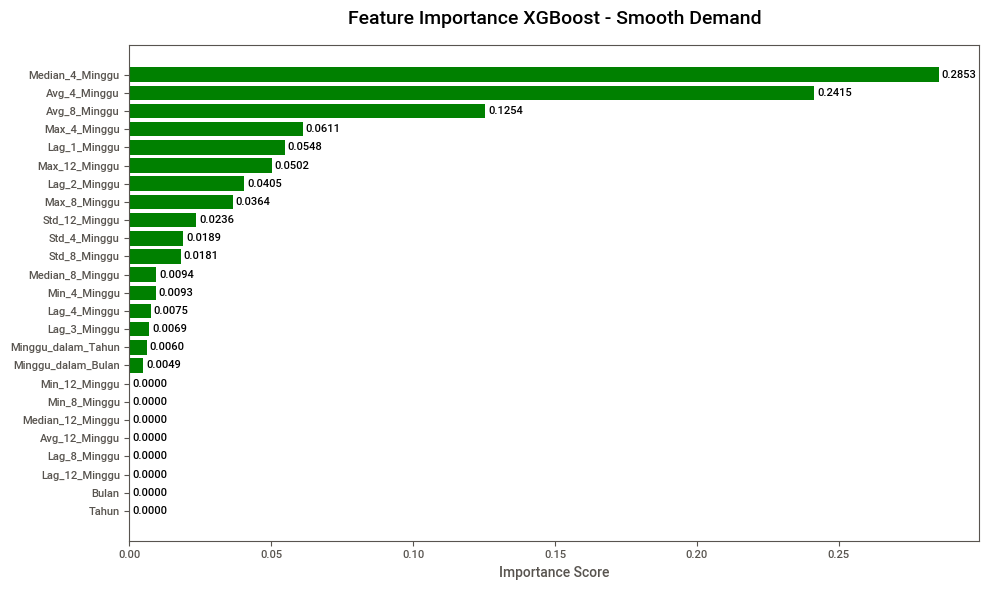

In [91]:
importance_smooth_xgb = xgboost_feature_importance(
    model=xgb_smooth,
    feature_names=features,
    title="Feature Importance XGBoost - Smooth Demand"
)

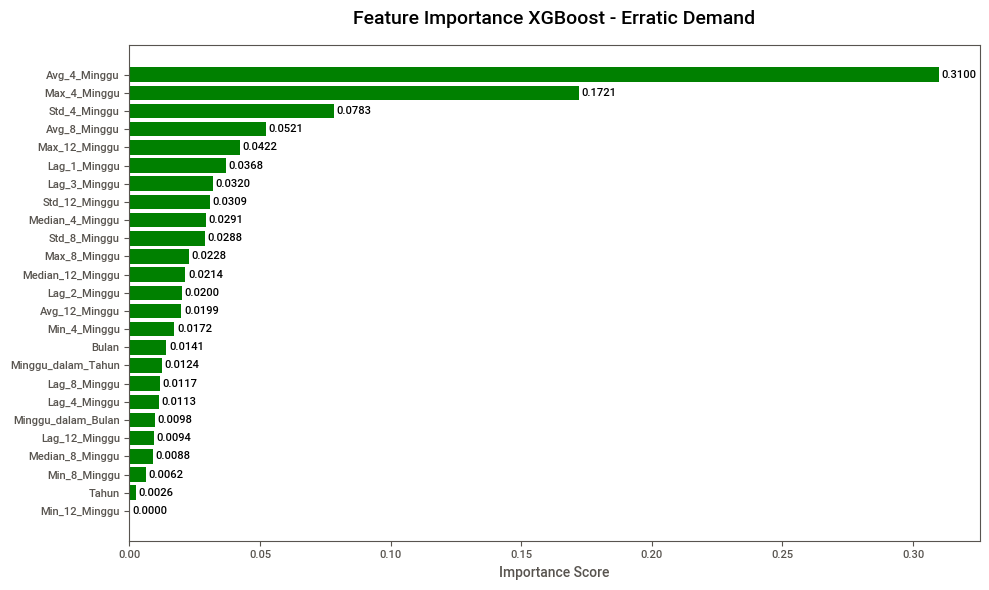

In [92]:
importance_erractic_xgb = xgboost_feature_importance(
    model=xgb_erractic,
    feature_names=features,
    title="Feature Importance XGBoost - Erratic Demand"
)

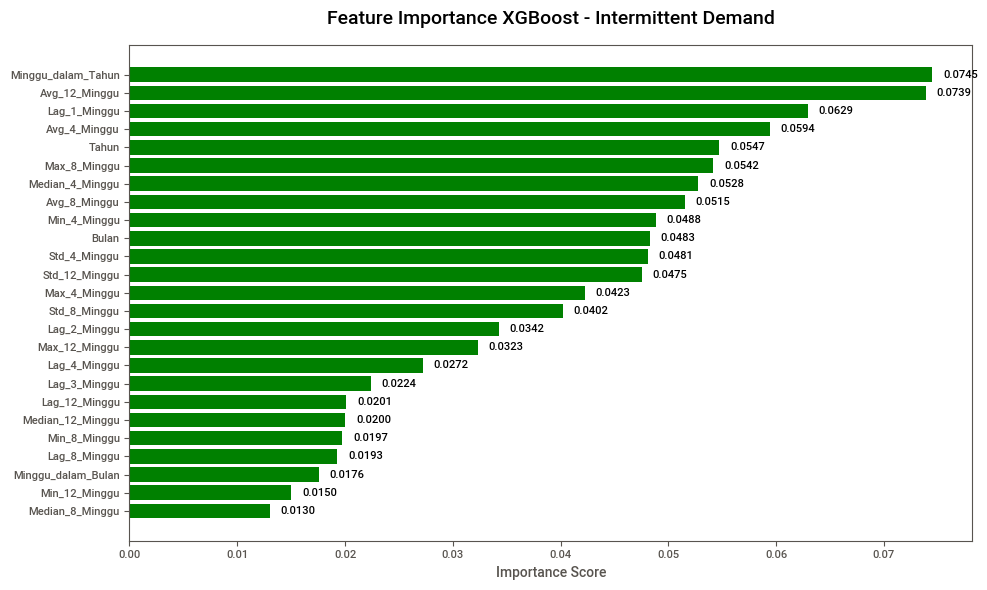

In [93]:
importance_intermittent_xgb = xgboost_feature_importance(
    model=xgb_intermittent,
    feature_names=features,
    title="Feature Importance XGBoost - Intermittent Demand"
)

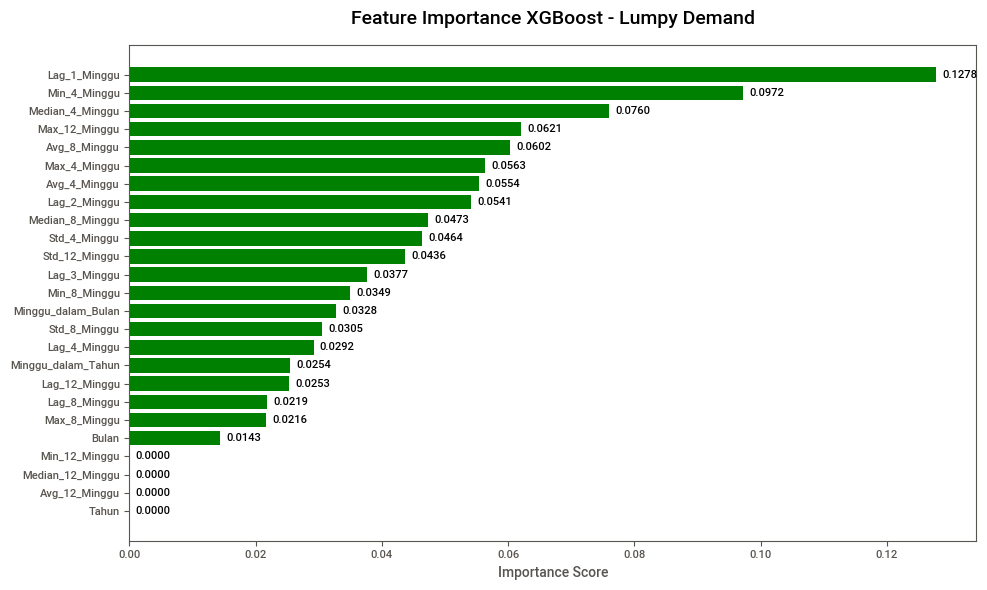

In [94]:
importance_lumpy_xgb = xgboost_feature_importance(
    model=xgb_lumpy,
    feature_names=features,
    title="Feature Importance XGBoost - Lumpy Demand"
)

## 9.2 TabNet

In [95]:
# Split Data X-Y for TabNet

X_train_all = X_train_all.values
y_train_all = y_train_all.values.reshape(-1, 1)
X_val_all   = X_val_all.values
y_val_all   = y_val_all.values.reshape(-1, 1)
X_test_all  = X_test_all.values
y_test_all  = y_test_all.values.reshape(-1, 1)

X_train_smooth = X_train_smooth.values
y_train_smooth = y_train_smooth.values.reshape(-1, 1)
X_val_smooth   = X_val_smooth.values
y_val_smooth   = y_val_smooth.values.reshape(-1, 1)
X_test_smooth  = X_test_smooth.values
y_test_smooth  = y_test_smooth.values.reshape(-1, 1)

X_train_erratic = X_train_erratic.values
y_train_erratic = y_train_erratic.values.reshape(-1, 1)
X_val_erratic   = X_val_erratic.values
y_val_erratic   = y_val_erratic.values.reshape(-1, 1)
X_test_erratic  = X_test_erratic.values
y_test_erratic  = y_test_erratic.values.reshape(-1, 1)

X_train_intermittent = X_train_intermittent.values
y_train_intermittent = y_train_intermittent.values.reshape(-1, 1)
X_val_intermittent   = X_val_intermittent.values
y_val_intermittent   = y_val_intermittent.values.reshape(-1, 1)
X_test_intermittent  = X_test_intermittent.values
y_test_intermittent  = y_test_intermittent.values.reshape(-1, 1)

X_train_lumpy = X_train_lumpy.values
y_train_lumpy = y_train_lumpy.values.reshape(-1, 1)
X_val_lumpy   = X_val_lumpy.values
y_val_lumpy   = y_val_lumpy.values.reshape(-1, 1)
X_test_lumpy  = X_test_lumpy.values
y_test_lumpy  = y_test_lumpy.values.reshape(-1, 1)

### a. Predict

In [96]:
# Semua Produk
y_pred_all_tab_train = tabnet_all.predict(X_train_all).ravel()
y_pred_all_tab_val   = tabnet_all.predict(X_val_all).ravel()
y_pred_all_tab_test = tabnet_all.predict(X_test_all).ravel()

# Produk Smooth Demand
y_pred_smooth_tab_train = tabnet_smooth.predict(X_train_smooth).ravel()
y_pred_smooth_tab_val   = tabnet_smooth.predict(X_val_smooth).ravel()
y_pred_smooth_tab_test = tabnet_smooth.predict(X_test_smooth).ravel()

# Produk Erratic Demand
y_pred_erratic_tab_train = tabnet_erractic.predict(X_train_erratic).ravel()
y_pred_erratic_tab_val   = tabnet_erractic.predict(X_val_erratic).ravel()
y_pred_erratic_tab_test = tabnet_erractic.predict(X_test_erratic).ravel()

# Produk Intermittent Demand 
y_pred_intermittent_tab_train = tabnet_intermittent.predict(X_train_intermittent).ravel()
y_pred_intermittent_tab_val   = tabnet_intermittent.predict(X_val_intermittent).ravel()
y_pred_intermittent_tab_test = tabnet_intermittent.predict(X_test_intermittent).ravel()

# Produk Lumpy Demand
y_pred_lumpy_tab_train = tabnet_lumpy.predict(X_train_lumpy).ravel()
y_pred_lumpy_tab_val   = tabnet_lumpy.predict(X_val_lumpy).ravel()
y_pred_lumpy_tab_test = tabnet_lumpy.predict(X_test_lumpy).ravel()

### b. Evaluation

#### MAE, R2, LOR

In [97]:
hasil_perbandingan_tabnet = pd.DataFrame([

    evaluate_forecasting(
        y_train_all.ravel(), y_pred_all_tab_train,
        y_val_all.ravel(), y_pred_all_tab_val,
        y_test_all.ravel(), y_pred_all_tab_test,
        "All Product"
    ),

    evaluate_forecasting(
        y_train_smooth.ravel(), y_pred_smooth_tab_train,
        y_val_smooth.ravel(), y_pred_smooth_tab_val,
        y_test_smooth.ravel(), y_pred_smooth_tab_test,
        "Smooth Demand"
    ),

    evaluate_forecasting(
        y_train_erratic.ravel(), y_pred_erratic_tab_train,
        y_val_erratic.ravel(), y_pred_erratic_tab_val,
        y_test_erratic.ravel(), y_pred_erratic_tab_test,
        "Erratic Demand"
    ),

    evaluate_forecasting(
        y_train_intermittent.ravel(), y_pred_intermittent_tab_train,
        y_val_intermittent.ravel(), y_pred_intermittent_tab_val,
        y_test_intermittent.ravel(), y_pred_intermittent_tab_test,
        "Intermittent Demand"
    ),

    evaluate_forecasting(
        y_train_lumpy.ravel(), y_pred_lumpy_tab_train,
        y_val_lumpy.ravel(), y_pred_lumpy_tab_val,
        y_test_lumpy.ravel(), y_pred_lumpy_tab_test,
        "Lumpy Demand"
    )

])

hasil_perbandingan_tabnet

,Kategori Data,MAE Train,MAE Val,MAE Test,R2 Train,R2 Val,R2 Test,Gap Train-Val (%),Gap Train-Test (%),LOR,Status LOR
0,All Product,9.45,8.89,10.30,0.344,0.548,0.394,-5.91,9.01,-0.086,Overfitting
1,Smooth Demand,7.54,6.73,6.71,0.520,0.795,0.825,-10.68,-11.02,0.117,Underfitting
2,Erratic Demand,14.69,14.96,20.48,0.326,0.513,0.152,1.86,39.42,-0.332,Overfitting
3,Intermittent Demand,2.37,2.59,3.00,0.422,0.571,0.447,9.30,26.41,-0.234,Overfitting
4,Lumpy Demand,9.23,5.60,8.06,-0.052,0.005,-0.002,-39.35,-12.73,0.136,Underfitting


#### Data Aktual vs Prediksi

In [98]:
hasil_smooth_tab_train = compare_prediksi_aktual(
    y_train_smooth,
    y_pred_smooth_tab_train,
    train_smooth,
    label="TabNet - Smooth Demand (Train)"
)


===== TabNet - Smooth Demand (Train) =====
MAE Keseluruhan      : 7.5380
Proporsi Qty = 0     : 9.13%
MAE Qty = 0          : 7.9729
MAE Qty > 0          : 7.4943


In [99]:
hasil_smooth_tab_val = compare_prediksi_aktual(
    y_val_smooth,
    y_pred_smooth_tab_val,
    val_smooth,
    label="TabNet - Smooth Demand (Validation)"
)


===== TabNet - Smooth Demand (Validation) =====
MAE Keseluruhan      : 6.7332
Proporsi Qty = 0     : 5.49%
MAE Qty = 0          : 8.4754
MAE Qty > 0          : 6.6320


In [100]:
hasil_smooth_tab_test = compare_prediksi_aktual(
    y_test_smooth,
    y_pred_smooth_tab_test,
    test_smooth,
    label="TabNet - Smooth Demand (Test)"
)


===== TabNet - Smooth Demand (Test) =====
MAE Keseluruhan      : 6.7075
Proporsi Qty = 0     : 8.71%
MAE Qty = 0          : 6.4158
MAE Qty > 0          : 6.7353


#### Analisis Error per Produk

In [101]:
error_produk_smooth_tabnet_val = analisis_per_produk(
    y_val_smooth,
    y_pred_smooth_tab_val,
    val_smooth
)

error_produk_smooth_tabnet_val.sort_values('Nama Barang')

,Nama Barang,Min,Q1,Q2,Q3,Max,MAE
0,BOTOL ALMOND 250ML,100.00,200.00,212.50,351.25,460.00,81.86
1,CUP JAXINE 55/60 ML,8.00,9.00,11.50,15.25,19.00,3.78
2,DM RECT 750 ML,2.00,3.15,4.12,5.05,7.20,2.08
3,EURO GOURMET EXTRA PEDAS 1 KG,0.00,3.50,6.50,9.25,15.00,3.94
4,FOAM KCS 2,4.12,8.46,10.42,12.78,22.08,3.98
5,FOAM KCS 3,1.22,2.53,3.45,4.13,5.13,1.19
6,GELAS SLIM 'TEN-TEN' 18 OZ,0.00,30.50,46.00,53.75,86.00,21.90
7,GELAS TECHNO 10 OZ,9.00,14.00,16.00,18.00,29.00,6.59
8,GELAS TECHNO 12 OZ,3.00,6.00,7.50,10.25,13.00,3.08
9,GELAS TECHNO 14 OZ,0.00,22.75,35.00,41.50,51.00,14.48


In [102]:
error_produk_smooth_tabnet_test = analisis_per_produk(
    y_test_smooth,
    y_pred_smooth_tab_test,
    test_smooth
)

error_produk_smooth_tabnet_test.sort_values("Nama Barang")

,Nama Barang,Min,Q1,Q2,Q3,Max,MAE
0,BOTOL ALMOND 250ML,115.00,182.75,231.50,322.00,420.00,91.49
1,CUP JAXINE 55/60 ML,2.00,6.00,8.50,11.75,22.00,5.11
2,DM RECT 750 ML,0.00,0.00,0.22,2.30,4.00,1.57
3,EURO GOURMET EXTRA PEDAS 1 KG,4.00,8.75,10.00,13.50,21.00,4.73
4,FOAM KCS 2,6.00,7.40,7.93,9.23,13.50,1.64
5,FOAM KCS 3,0.00,0.86,1.27,2.85,6.22,1.71
6,GELAS SLIM 'TEN-TEN' 18 OZ,0.00,13.75,36.50,57.25,70.00,21.45
7,GELAS TECHNO 10 OZ,0.00,6.00,9.00,13.25,27.00,6.16
8,GELAS TECHNO 12 OZ,3.00,8.75,10.50,12.25,17.00,3.41
9,GELAS TECHNO 14 OZ,6.00,18.00,28.00,37.50,61.00,11.06


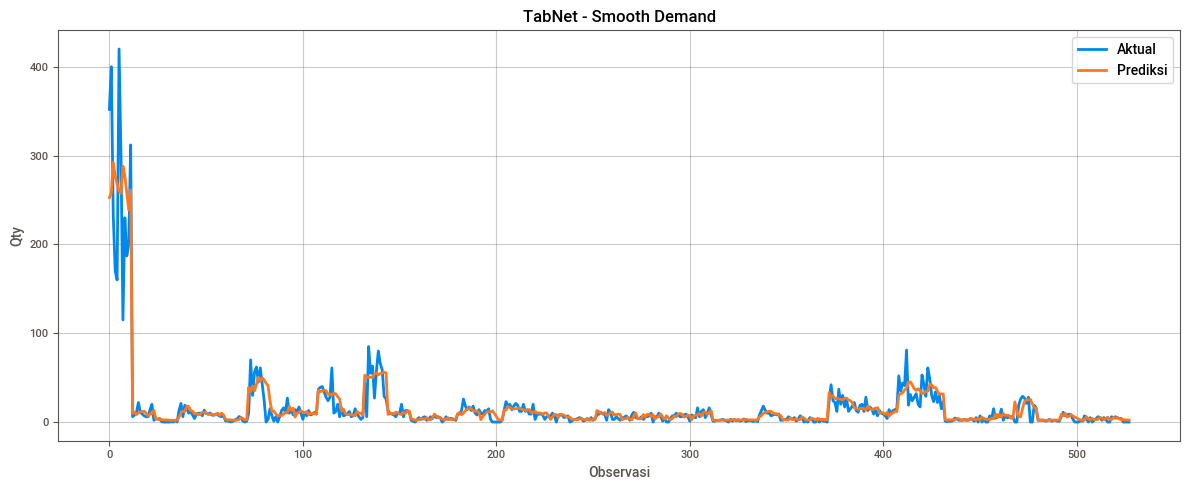

In [103]:
plot_prediksi_vs_aktual(
    y_test_smooth,
    y_pred_smooth_tab_test,
    "TabNet - Smooth Demand"
)

### c. Feature Importance

In [104]:
def tabnet_feature_importance(
    model,
    X_train,
    feature_names,
    title="Feature Importance TabNet",
    color="blue"
):

    explain_matrix, masks = model.explain(X_train)
    feature_importance = np.mean(explain_matrix, axis=0)
    indices = np.argsort(feature_importance)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        range(len(feature_importance)),
        feature_importance[indices],
        color=color,
        align='center'
    )

    for bar, val in zip(bars, feature_importance[indices]):
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            ha='left', va='center',
            fontsize=8, fontweight='bold'
        )

    ax.set_yticks(range(len(feature_importance)))
    ax.set_yticklabels([feature_names[idx] for idx in indices])
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    return feature_importance

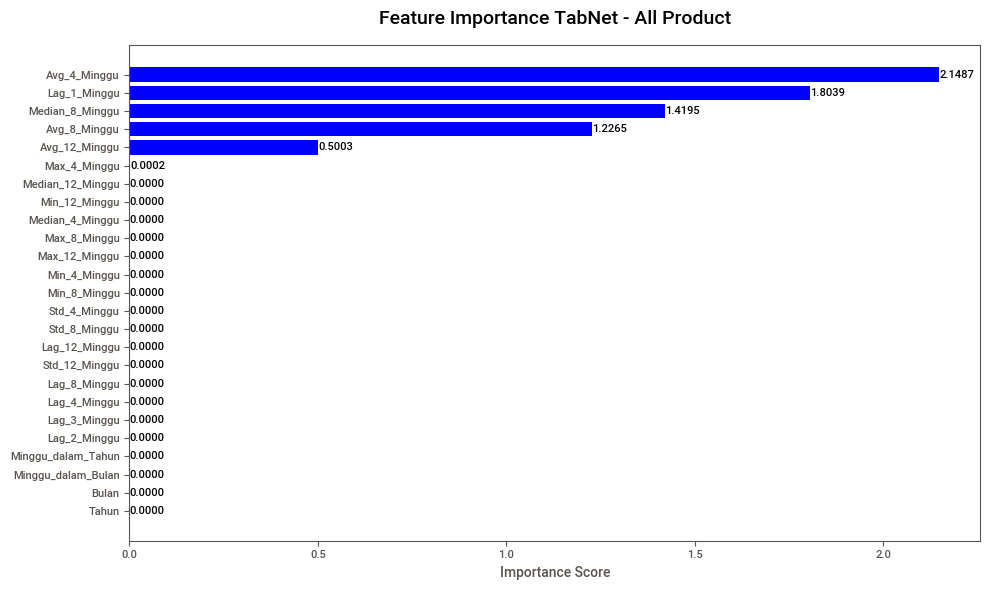

In [105]:
importance_all_tabnet = tabnet_feature_importance(
    model=tabnet_all,
    X_train=X_train_all,
    feature_names=features,
    title="Feature Importance TabNet - All Product"
)

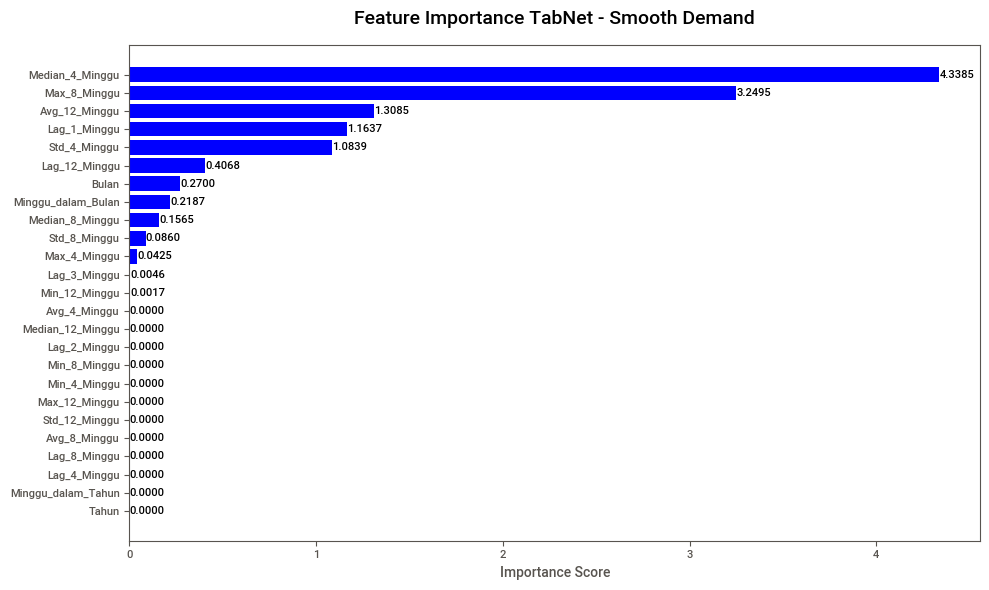

In [106]:
importance_smooth_tabnet = tabnet_feature_importance(
    model=tabnet_smooth,
    X_train=X_train_smooth,
    feature_names=features,
    title="Feature Importance TabNet - Smooth Demand"
)

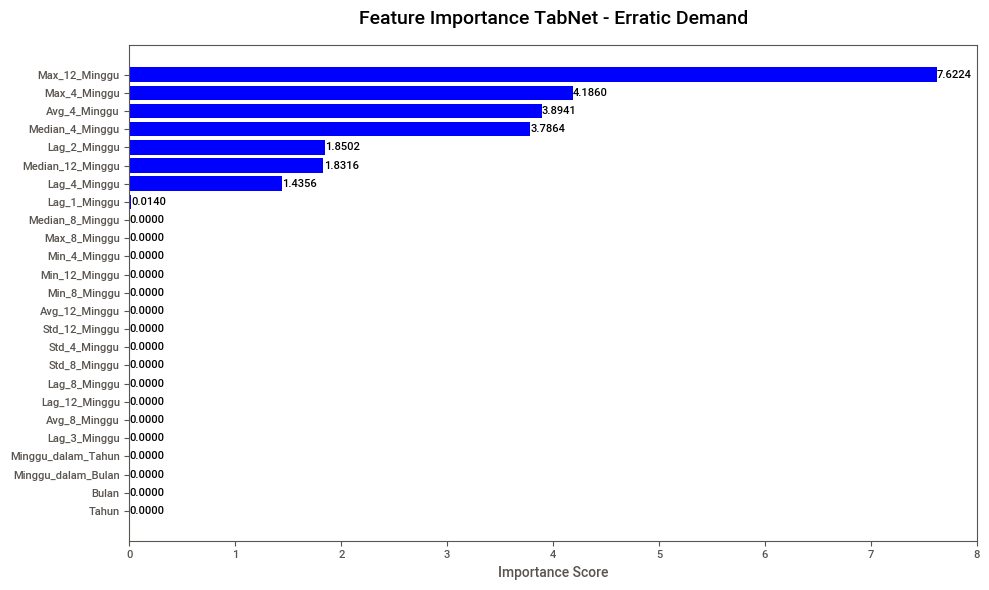

In [107]:
importance_erractic_tabnet = tabnet_feature_importance(
    model=tabnet_erractic,
    X_train=X_train_erratic,
    feature_names=features,
    title="Feature Importance TabNet - Erratic Demand"
)

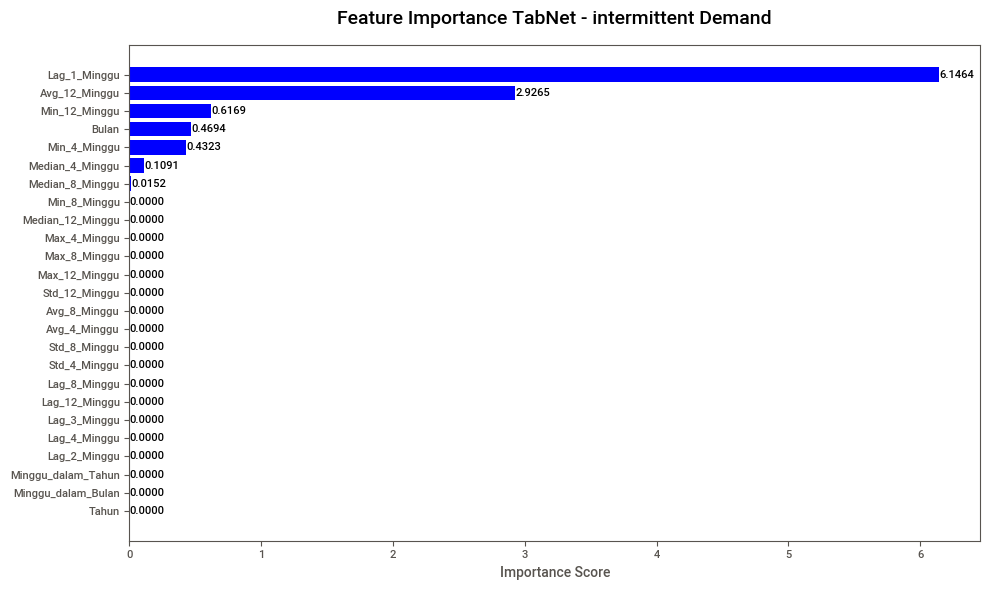

In [108]:
importance_intermittent_tabnet = tabnet_feature_importance(
    model=tabnet_intermittent,
    X_train=X_train_intermittent,
    feature_names=features,
    title="Feature Importance TabNet - intermittent Demand"
)

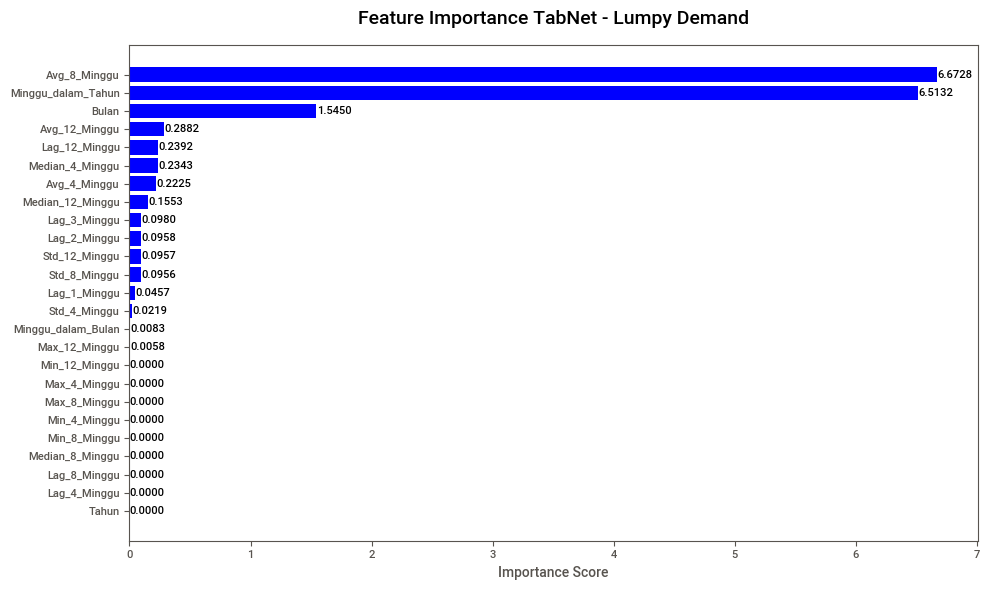

In [109]:
importance_lumpy_tabnet = tabnet_feature_importance(
    model=tabnet_lumpy,
    X_train=X_train_lumpy,
    feature_names=features,
    title="Feature Importance TabNet - Lumpy Demand"
)

# Visualisasi Chart Komparatif

In [110]:
labels = hasil_perbandingan_xgboost["Kategori Data"].tolist()

# MAE
mae_train_xgb = hasil_perbandingan_xgboost["MAE Train"].to_numpy()
mae_val_xgb   = hasil_perbandingan_xgboost["MAE Val"].to_numpy()
mae_test_xgb  = hasil_perbandingan_xgboost["MAE Test"].to_numpy()

mae_train_tab = hasil_perbandingan_tabnet["MAE Train"].to_numpy()
mae_val_tab   = hasil_perbandingan_tabnet["MAE Val"].to_numpy()
mae_test_tab  = hasil_perbandingan_tabnet["MAE Test"].to_numpy()

# R²
r2_train_xgb = hasil_perbandingan_xgboost["R2 Train"].to_numpy()
r2_val_xgb   = hasil_perbandingan_xgboost["R2 Val"].to_numpy()
r2_test_xgb  = hasil_perbandingan_xgboost["R2 Test"].to_numpy()

r2_train_tab = hasil_perbandingan_tabnet["R2 Train"].to_numpy()
r2_val_tab   = hasil_perbandingan_tabnet["R2 Val"].to_numpy()
r2_test_tab  = hasil_perbandingan_tabnet["R2 Test"].to_numpy()

# LOR
lor_xgb = hasil_perbandingan_xgboost["LOR"].to_numpy()
lor_tab = hasil_perbandingan_tabnet["LOR"].to_numpy()

# Warna
color_xgb = "#378ADD"
color_tab = "#D85A30"

x = np.arange(len(labels))
w = 0.13
width = 0.35

In [111]:
def add_value_labels(ax, bar_groups, offset=0.02, decimals=2):

    for bars in bar_groups:
        for bar in bars:
            height = bar.get_height()

            label = f"{height:.{decimals}f}"

            if height >= 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height + offset,
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    fontweight="bold"
                )
            else:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height - offset,
                    label,
                    ha="center",
                    va="top",
                    fontsize=8,
                    fontweight="bold"
                )

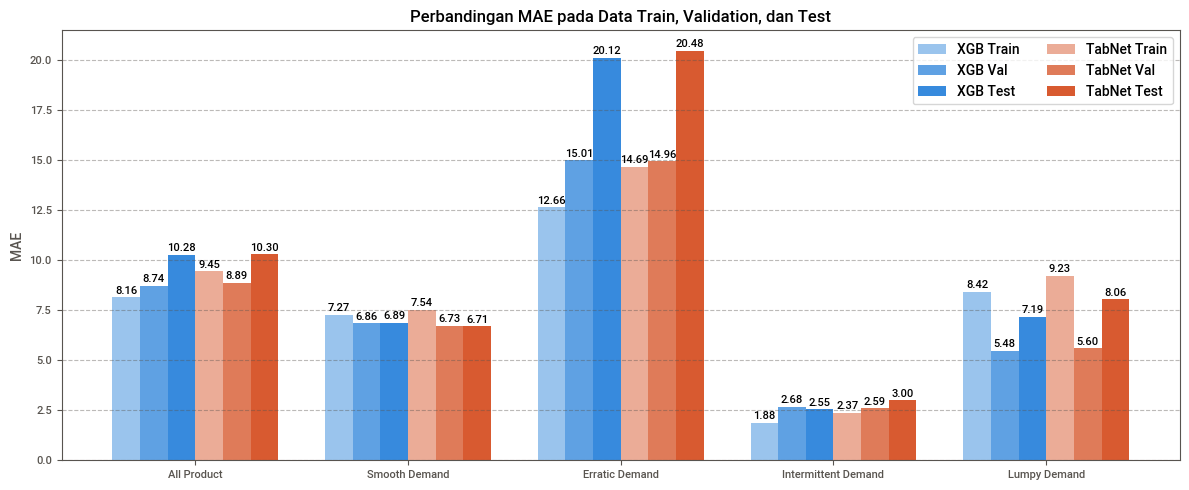

In [112]:
fig, ax = plt.subplots(figsize=(12,5))

b1 = ax.bar(x-2.5*w, mae_train_xgb, w, label="XGB Train", color=color_xgb,alpha=0.5)
b2 = ax.bar(x-1.5*w, mae_val_xgb,   w, label="XGB Val", color=color_xgb, alpha=0.8)
b3 = ax.bar(x-0.5*w, mae_test_xgb,  w, label="XGB Test", color=color_xgb)

b4 = ax.bar(x+0.5*w, mae_train_tab, w, label="TabNet Train", color=color_tab, alpha=0.5)
b5 = ax.bar(x+1.5*w, mae_val_tab,   w, label="TabNet Val", color=color_tab, alpha=0.8)
b6 = ax.bar(x+2.5*w, mae_test_tab,  w, label="TabNet Test", color=color_tab)

add_value_labels(ax,[b1,b2,b3,b4,b5,b6],0.08)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MAE")
ax.set_title("Perbandingan MAE pada Data Train, Validation, dan Test")
ax.legend(ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

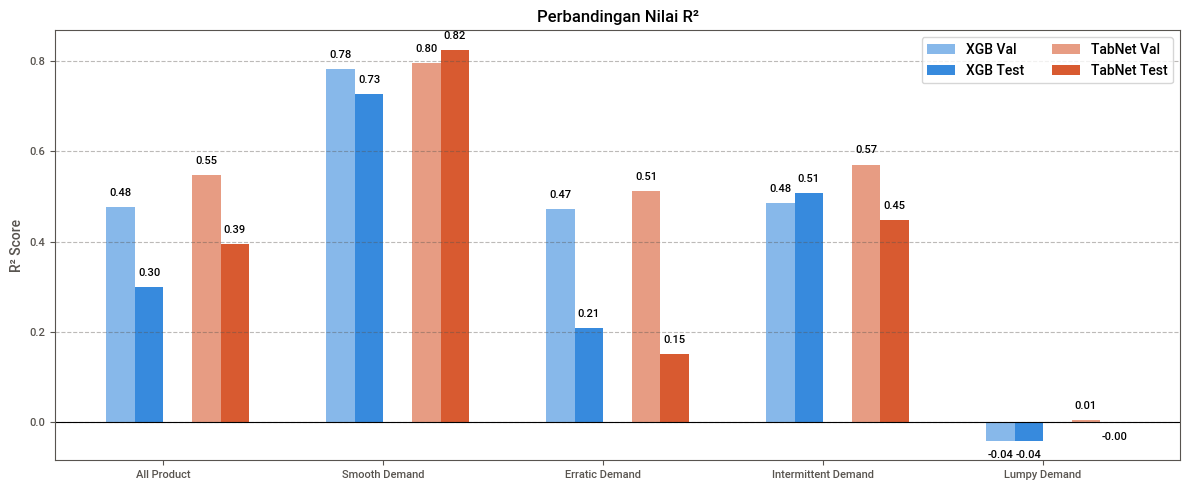

In [113]:
fig, ax = plt.subplots(figsize=(12,5))

c1 = ax.bar(x-1.5*w, r2_val_xgb,   w, label="XGB Val", color=color_xgb,alpha=0.6)
c2 = ax.bar(x-0.5*w, r2_test_xgb,  w, label="XGB Test", color=color_xgb)

c3 = ax.bar(x+1.5*w, r2_val_tab,   w, label="TabNet Val", color=color_tab, alpha=0.6)
c4 = ax.bar(x+2.5*w, r2_test_tab,  w, label="TabNet Test", color=color_tab)

# <-- cukup ini saja
add_value_labels(ax, [c1, c2, c3, c4], 0.02)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("R² Score")
ax.set_title("Perbandingan Nilai R²")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

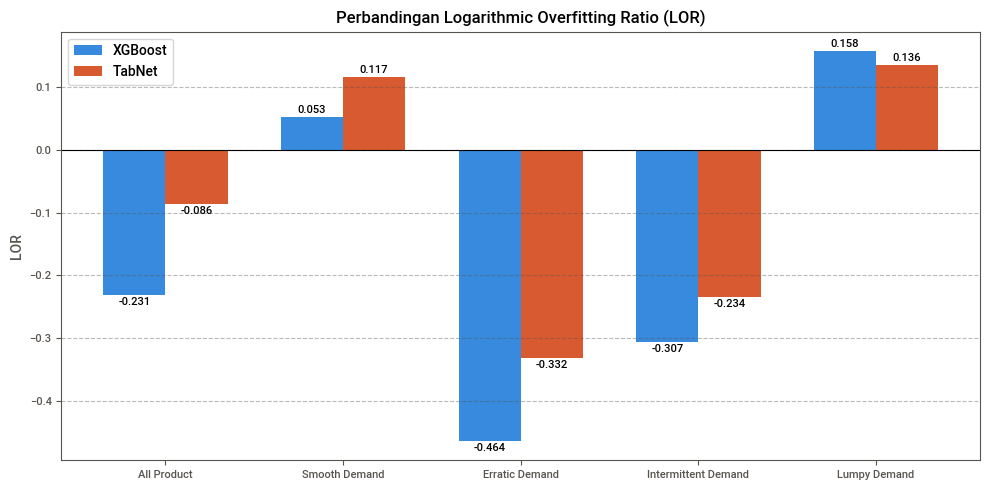

In [114]:
fig, ax = plt.subplots(figsize=(10,5))

d1 = ax.bar(x-width/2, lor_xgb, width,
            label="XGBoost",
            color=color_xgb)

d2 = ax.bar(x+width/2, lor_tab, width,
            label="TabNet",
            color=color_tab)

add_value_labels(ax,[d1,d2],0.003, decimals=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("LOR")
ax.set_title("Perbandingan Logarithmic Overfitting Ratio (LOR)")
ax.axhline(0,color="black",linewidth=0.8)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

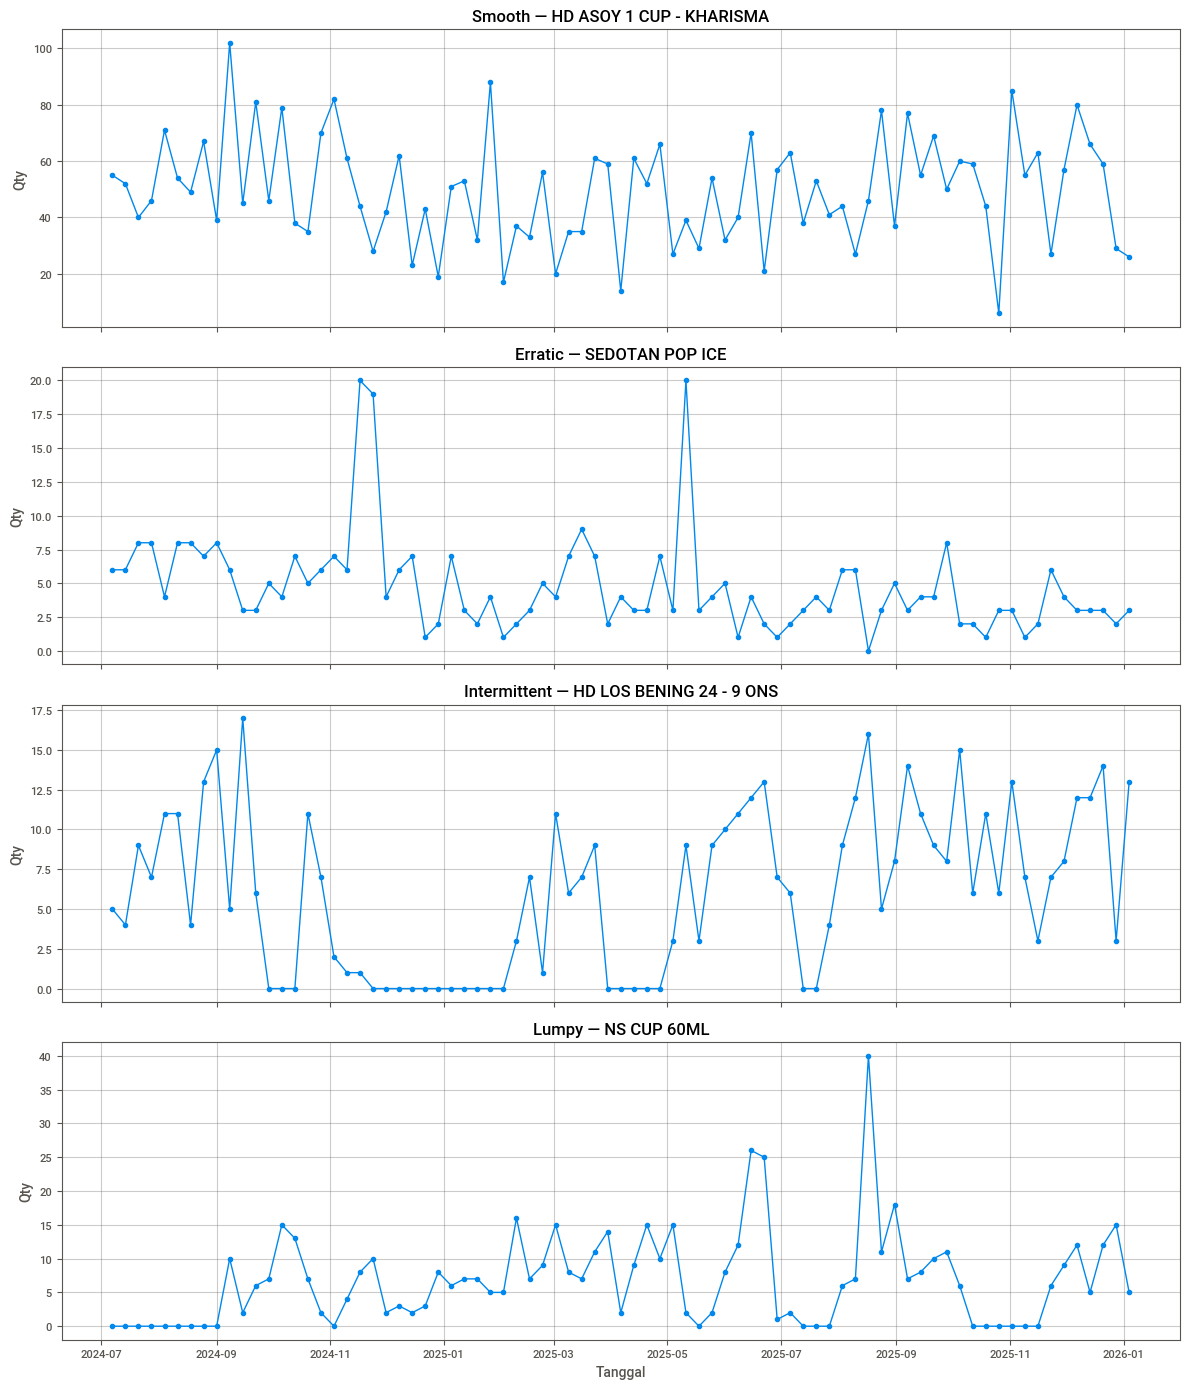

In [115]:
def plot_pola_demand_per_kategori(df_model, hasil_adi_cv2, kolom_qty="Qty_original"):
        
    kategori_list = ["Smooth", "Erratic", "Intermittent", "Lumpy"]
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    
    for i, kategori in enumerate(kategori_list):
        produk_kategori = hasil_adi_cv2[hasil_adi_cv2["Kategori"] == kategori]
        
        if len(produk_kategori) == 0:
            axes[i].set_title(f"{kategori} — tidak ada produk")
            continue
        
        nama_produk = produk_kategori["Nama Barang"].iloc[0]
        
        data_produk = (
            df_model[df_model["Nama Barang"] == nama_produk]
            .sort_values("Tanggal Transaksi")
        )
        
        axes[i].plot(
            data_produk["Tanggal Transaksi"],
            data_produk[kolom_qty],
            marker="o", markersize=3, linewidth=1
        )
        axes[i].set_title(f"{kategori} — {nama_produk}")
        axes[i].set_ylabel("Qty")
        axes[i].grid(alpha=0.3)
    
    axes[-1].set_xlabel("Tanggal")
    plt.tight_layout()
    plt.savefig("pola_demand_per_kategori.png", dpi=150)
    plt.show()


# --- Cara pakai ---
plot_pola_demand_per_kategori(df_model, hasil_adi_cv2, kolom_qty="Qty")